# PRACTICAL EXAM

#### Used Car Price Prediction

**Course: AI Algorithms and Predictions**  
**Dataset: “Moteur.ma_SDBDIA2A”**  
**Prof: Abdellah TAHIRI, Ph.D**  

# Part A – Data Collection
**Source :** https://www.moteur.ma/fr/voiture/achat-voiture-occasion/

L'objectif est d'extraire les annonces de voitures d'occasion depuis le site moteur.ma.  
On va d'abord explorer la structure HTML de la page, puis construire le scraper en deux versions : séquentielle et multi-threadée.

---
## — Exploration de la structure HTML

Avant d'écrire le scraper, on inspecte une seule page pour identifier les balises qui contiennent les données qui nous intéressent :

| Donnée | Balise HTML |
|---|---|
| Titre (Marque + Modèle) | `<h5 class="ads-index-title">` |
| Prix | `<h4 class="ad-price-grid">` |
| Ville | `<i class="fa-map-marker">` |
| Année / Transmission / Carburant / Kilométrage | `<div class="ad-meta">` → `<span>`  |
| Lien page détail | `<a href=...detail-annonce...>` |
| Puissance / Nb portes | `<tr>` dans la page détail |

Chaque annonce est encapsulée dans un `<div class="ads-index-card">`.  
La pagination fonctionne avec le paramètre `PAGES_TO_SCRAPE=N`.

In [ ]:
import requests
from bs4 import BeautifulSoup

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "fr-FR,fr;q=0.9,en;q=0.8",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
}

url = "https://www.moteur.ma/fr/voiture/achat-voiture-occasion/?page=1"
response = requests.get(url, headers=HEADERS, timeout=15)
soup = BeautifulSoup(response.text, "lxml")

cards = soup.find_all("div", class_="ads-index-card")
print(f"Nombre de cartes trouvées sur la page 1 : {len(cards)}")
print()

card = cards[0]
print("=== Titre ===")
print(card.find("h5", class_="ads-index-title"))
print()
print("=== Prix ===")
print(card.find("h4", class_="ad-price-grid"))
print()
print("=== Ville ===")
city_icon = card.find("i", class_="fa-map-marker")
print(city_icon.parent if city_icon else "Non trouvé")
print()
print("=== Meta (année / transmission / carburant / km) ===")
print(card.find("div", class_="ad-meta"))
print()
print("=== Lien détail ===")
import re
print(card.find("a", href=re.compile(r"detail-annonce")))

Nombre de cartes trouvées sur la page 1 : 30

=== Titre ===
<h5 class="font-weight-semibold mt-1 mb-2 ads-index-title">
                                                                Nissan Qashqai
                                                            </h5>

=== Prix ===
<h4 class="text-primary font-weight-bold pb-2 my-0 ad-price-grid">
                                                                                                                    163,000 MAD
                                                                                                            </h4>

=== Ville ===
<a class="me-4" href="javascript:void(0);">
<i class="fa fa-map-marker text-muted me-1"></i>
                                                            Safi
                                                        </a>

=== Meta (année / transmission / carburant / km) ===
<div class="d-inline-block gap-3 ad-meta">
<span class="text-muted">
<i class="fa fa-calendar me-1"></i>
                   

---
## — Scraper séquentiel

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

BASE_URL      = "https://www.moteur.ma/fr/voiture/achat-voiture-occasion/"
HEADERS       = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "fr-FR,fr;q=0.9,en;q=0.8",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
}
PAGES_TO_SCRAPE = 67


def scrape_detail_page(detail_url):
    extra = {"Puissance_fiscale": None, "Etat": "Occasion", "Nombre_portes": None}
    resp = requests.get(detail_url, headers=HEADERS, timeout=15)
    if resp.status_code != 200:
        return extra
    soup = BeautifulSoup(resp.text, "lxml")
    for tr in soup.find_all("tr"):
        tds = tr.find_all(["td", "th"])
        if len(tds) < 2:
            continue
        label = tds[0].get_text(strip=True).lower()
        value = tds[1].get_text(strip=True)
        if "puissance" in label and value:
            digits = re.sub(r"[^\d]", "", value)
            if digits:
                extra["Puissance_fiscale"] = int(digits)
        elif "porte" in label and value:
            digits = re.sub(r"[^\d]", "", value)
            if digits:
                extra["Nombre_portes"] = int(digits)
    return extra


def scrape_listing_page(page_num):
    url = f"{BASE_URL}?page={page_num}"
    cars = []
    response = requests.get(url, headers=HEADERS, timeout=15)
    if response.status_code != 200:
        return cars
    soup = BeautifulSoup(response.text, "lxml")
    cards = soup.find_all("div", class_="ads-index-card")
    for card in cards:
        title_tag = card.find("h5", class_="ads-index-title")
        title = title_tag.text.strip() if title_tag else ""

        price_tag = card.find("h4", class_="ad-price-grid")
        price_raw = price_tag.text.strip() if price_tag else ""
        price_digits = re.sub(r"[^\d]", "", price_raw)
        price = int(price_digits) if price_digits else None

        city = None
        city_icon = card.find("i", class_="fa-map-marker")
        if city_icon and city_icon.parent:
            city = city_icon.parent.get_text(strip=True)

        year = transmission = fuel = mileage = None
        meta_div = card.find("div", class_="ad-meta")
        if meta_div:
            for span in meta_div.find_all("span"):
                icon = span.find("i")
                if not icon:
                    continue
                classes = icon.get("class", [])
                text = span.get_text(strip=True)
                if "fa-calendar" in classes:
                    match = re.search(r"(19|20)\d{2}", text)
                    year = int(match.group()) if match else None
                elif "fa-cog" in classes:
                    transmission = text
                elif "fa-tachometer" in classes:
                    fuel = text
                elif "fa-road" in classes:
                    km_digits = re.sub(r"[^\d]", "", text)
                    mileage = int(km_digits) if km_digits else None

        link_tag = card.find("a", href=re.compile(r"detail-annonce"))
        detail_url = link_tag["href"] if link_tag else None

        cars.append({
            "Titre": title,
              "Prix": price,
                "Ville": city,
            "Annee": year, "Kilometrage": mileage,
            "Transmission": transmission, "Carburant": fuel,
            "URL": detail_url,
        })
    return cars


all_cars = []
for page in range(1, PAGES_TO_SCRAPE + 1):
    page_cars = scrape_listing_page(page)
    if not page_cars:
        print(f"Page {page} vide — arrêt.")
        break
    all_cars.extend(page_cars)
    print(f"Page {page:>3} -> {len(page_cars):>2} annonces | Total: {len(all_cars)}")
    time.sleep(1.5)

for i, car in enumerate(all_cars):
    if car["URL"]:
        url = car["URL"]
        if not url.startswith("http"):
            url = "https://www.moteur.ma" + url
        car.update(scrape_detail_page(url))
        time.sleep(0.8)

df = pd.DataFrame(all_cars)
parts = df["Titre"].str.split(n=1, expand=True)
df["Marque"] = parts[0]
df["Modele"] = parts[1]

df.to_csv("moteur_raw.csv", index=False)
print(f"\n{len(df)} annonces sauvegardées dans moteur_raw.csv")
print(df.head(10).to_string())

Page   1 -> 30 annonces | Total: 30
Page   2 -> 30 annonces | Total: 60
Page   3 -> 30 annonces | Total: 90
Page   4 -> 30 annonces | Total: 120
Page   5 -> 30 annonces | Total: 150
Page   6 -> 30 annonces | Total: 180
Page   7 -> 30 annonces | Total: 210
Page   8 -> 30 annonces | Total: 240
Page   9 -> 30 annonces | Total: 270
Page  10 -> 30 annonces | Total: 300
Page  11 -> 30 annonces | Total: 330
Page  12 -> 30 annonces | Total: 360
Page  13 -> 30 annonces | Total: 390
Page  14 -> 30 annonces | Total: 420
Page  15 -> 30 annonces | Total: 450
Page  16 -> 30 annonces | Total: 480
Page  17 -> 30 annonces | Total: 510
Page  18 -> 30 annonces | Total: 540
Page  19 -> 30 annonces | Total: 570
Page  20 -> 30 annonces | Total: 600
Page  21 -> 30 annonces | Total: 630
Page  22 -> 30 annonces | Total: 660
Page  23 -> 30 annonces | Total: 690
Page  24 -> 30 annonces | Total: 720
Page  25 -> 30 annonces | Total: 750
Page  26 -> 30 annonces | Total: 780
Page  27 -> 30 annonces | Total: 810
Page

---
## Problème de performance

La version séquentielle scrape les pages détail **une par une**.  
Avec ~2000 annonces et 0.8s d'attente entre chaque requête, cela représente :

> **2000 × 0.8s ≈ 26 minutes** juste pour les pages détail

La solution : utiliser le **multithreading** avec `ThreadPoolExecutor`.  
Au lieu de traiter les pages détail une à une, on en lance **10 en parallèle** simultanément, ce qui divise le temps par ~10.

---
##  — Scraper multi-threadé

In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
from concurrent.futures import ThreadPoolExecutor, as_completed

BASE_URL        = "https://www.moteur.ma/fr/voiture/achat-voiture-occasion/"
HEADERS         = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "fr-FR,fr;q=0.9,en;q=0.8",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
}
PAGES_TO_SCRAPE = 67
DETAIL_THREADS  = 10


def scrape_detail_page(detail_url):
    extra = {"Puissance_fiscale": None, "Etat": "Occasion", "Nombre_portes": None}
    resp = requests.get(detail_url, headers=HEADERS, timeout=15)
    if resp.status_code != 200:
        return extra
    soup = BeautifulSoup(resp.text, "lxml")
    for tr in soup.find_all("tr"):
        tds = tr.find_all(["td", "th"])
        if len(tds) < 2:
            continue
        label = tds[0].get_text(strip=True).lower()
        value = tds[1].get_text(strip=True)
        if "puissance" in label and value:
            digits = re.sub(r"[^\d]", "", value)
            if digits:
                extra["Puissance_fiscale"] = int(digits)
        elif "porte" in label and value:
            digits = re.sub(r"[^\d]", "", value)
            if digits:
                extra["Nombre_portes"] = int(digits)
    return extra


def scrape_listing_page(page_num):
    url = f"{BASE_URL}?page={page_num}"
    cars = []
    response = requests.get(url, headers=HEADERS, timeout=15)
    if response.status_code != 200:
        return cars
    soup = BeautifulSoup(response.text, "lxml")
    cards = soup.find_all("div", class_="ads-index-card")
    for card in cards:
        title_tag = card.find("h5", class_="ads-index-title")
        title = title_tag.text.strip() if title_tag else ""

        price_tag = card.find("h4", class_="ad-price-grid")
        price_raw = price_tag.text.strip() if price_tag else ""
        price_digits = re.sub(r"[^\d]", "", price_raw)
        price = int(price_digits) if price_digits else None

        city = None
        city_icon = card.find("i", class_="fa-map-marker")
        if city_icon and city_icon.parent:
            city = city_icon.parent.get_text(strip=True)

        year = transmission = fuel = mileage = None
        meta_div = card.find("div", class_="ad-meta")
        if meta_div:
            for span in meta_div.find_all("span"):
                icon = span.find("i")
                if not icon:
                    continue
                classes = icon.get("class", [])
                text = span.get_text(strip=True)
                if "fa-calendar" in classes:
                    match = re.search(r"(19|20)\d{2}", text)
                    year = int(match.group()) if match else None
                elif "fa-cog" in classes:
                    transmission = text
                elif "fa-tachometer" in classes:
                    fuel = text
                elif "fa-road" in classes:
                    km_digits = re.sub(r"[^\d]", "", text)
                    mileage = int(km_digits) if km_digits else None

        link_tag = card.find("a", href=re.compile(r"detail-annonce"))
        detail_url = link_tag["href"] if link_tag else None

        cars.append({
            "Titre": title, "Prix": price, "Ville": city,
            "Annee": year, "Kilometrage": mileage,
            "Transmission": transmission, "Carburant": fuel,
            "URL": detail_url,
        })
    return cars


def scrape_detail_worker(args):
    index, car = args
    url = car["URL"]
    if not url:
        return index, {"Puissance_fiscale": None, "Etat": "Occasion", "Nombre_portes": None}
    if not url.startswith("http"):
        url = "https://www.moteur.ma" + url
    return index, scrape_detail_page(url)


all_cars = []
for page in range(1, PAGES_TO_SCRAPE + 1):
    page_cars = scrape_listing_page(page)
    if not page_cars:
        print(f"Page {page} vide — arrêt.")
        break
    all_cars.extend(page_cars)
    print(f"Page {page:>3} -> {len(page_cars):>2} annonces | Total: {len(all_cars)}")
    time.sleep(1.5)

print(f"\nScraping des pages détail avec {DETAIL_THREADS} threads...")
start_time = time.time()
done_count = 0

with ThreadPoolExecutor(max_workers=DETAIL_THREADS) as executor:
    futures = {executor.submit(scrape_detail_worker, (i, car)): i for i, car in enumerate(all_cars)}
    for future in as_completed(futures):
        index, extras = future.result()
        all_cars[index].update(extras)
        done_count += 1
        if done_count % 50 == 0:
            elapsed = time.time() - start_time
            remaining = (len(all_cars) - done_count) / (done_count / elapsed)
            print(f"  Pages détail: {done_count}/{len(all_cars)} (~{remaining:.0f}s restants)")

df = pd.DataFrame(all_cars)
parts = df["Titre"].str.split(n=1, expand=True)
df["Marque"] = parts[0]
df["Modele"] = parts[1]

df.to_csv("moteur_raw.csv", index=False)
print(f"\n{len(df)} annonces sauvegardées dans moteur_raw.csv")
print(df.head(10).to_string())

Page   1 -> 30 annonces | Total: 30
Page   2 -> 30 annonces | Total: 60
Page   3 -> 30 annonces | Total: 90
Page   4 -> 30 annonces | Total: 120
Page   5 -> 30 annonces | Total: 150
Page   6 -> 30 annonces | Total: 180
Page   7 -> 30 annonces | Total: 210
Page   8 -> 30 annonces | Total: 240
Page   9 -> 30 annonces | Total: 270
Page  10 -> 30 annonces | Total: 300
Page  11 -> 30 annonces | Total: 330
Page  12 -> 30 annonces | Total: 360
Page  13 -> 30 annonces | Total: 390
Page  14 -> 30 annonces | Total: 420
Page  15 -> 30 annonces | Total: 450
Page  16 -> 30 annonces | Total: 480
Page  17 -> 30 annonces | Total: 510
Page  18 -> 30 annonces | Total: 540
Page  19 -> 30 annonces | Total: 570
Page  20 -> 30 annonces | Total: 600
Page  21 -> 30 annonces | Total: 630
Page  22 -> 30 annonces | Total: 660
Page  23 -> 30 annonces | Total: 690
Page  24 -> 30 annonces | Total: 720
Page  25 -> 30 annonces | Total: 750
Page  26 -> 30 annonces | Total: 780
Page  27 -> 30 annonces | Total: 810
Page

## Conclusion

Dans cette première partie, nous avons mis en place un pipeline complet de collecte de données depuis le site **moteur.ma**.

L'exploration de la structure HTML nous a permis d'identifier avec précision les balises contenant les informations utiles de chaque annonce. Le scraper séquentiel, bien que fonctionnel, s'est révélé trop lent pour traiter l'ensemble des pages détail (~26 minutes). L'introduction du **multithreading** avec `ThreadPoolExecutor` a permis de réduire ce temps d'un facteur 10, rendant la collecte viable à grande échelle.

Au total, **~2000 annonces** ont été extraites sur **67 pages**, avec les features suivantes :

| Feature | Source |
|---|---|
| Marque / Modèle | Titre de l'annonce |
| Prix | Page listing |
| Ville | Page listing |
| Année / Kilométrage | Page listing (meta) |
| Transmission / Carburant | Page listing (meta) |
| Puissance fiscale / Nombre de portes | Page détail |

Le dataset brut est sauvegardé dans `moteur_raw.csv` .

# PART B – Data Exploratory Analysis

## 1. Importing the libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# %pip install missingno
import missingno

import warnings
warnings.filterwarnings('ignore')

sns.set_style("white")

COLOR = "#2A7DB5"


## 2. Importing the data

In [7]:
dataset = pd.read_csv('moteur_raw.csv')
print(f"Nombre d'observations : {len(dataset)}")

Nombre d'observations : 2010


In [8]:
# Dataset dimensions
print(f"Shape du dataset : {dataset.shape}")
print(f"Nombre de lignes : {dataset.shape[0]}")
print(f"Nombre de colonnes : {dataset.shape[1]}")

Shape du dataset : (2010, 13)
Nombre de lignes : 2010
Nombre de colonnes : 13


In [9]:
# First rows
dataset.head(10)

,Titre,Prix,Ville,Annee,Kilometrage,Transmission,Carburant,URL,Puissance_fiscale,Etat,Nombre_portes,Marque,Modele
0,Kia Picanto,98000.0,Casablanca,2022.0,81000,Manuelle,Essence,https://www.moteur.ma/fr/voiture/achat-voiture...,NaN,Occasion,5.0,Kia,Picanto
1,Hyundai Tucson,278000.0,Marrakech,2023.0,67000,Automatique,Diesel,https://www.moteur.ma/fr/voiture/achat-voiture...,NaN,Occasion,5.0,Hyundai,Tucson
2,Mitsubishi L200,115000.0,NaN,2014.0,439500,Manuelle,Diesel,https://www.moteur.ma/fr/voiture/achat-voiture...,10.0,Occasion,NaN,Mitsubishi,L200
3,Dacia Sandero,104000.0,NaN,2019.0,85000,Manuelle,Diesel,https://www.moteur.ma/fr/voiture/achat-voiture...,6.0,Occasion,NaN,Dacia,Sandero
4,Volkswagen Golf 7,205000.0,Casablanca,2021.0,156000,Automatique,Diesel,https://www.moteur.ma/fr/voiture/achat-voiture...,NaN,Occasion,5.0,Volkswagen,Golf 7
5,Peugeot 308,245000.0,Casablanca,2025.0,24000,Automatique,Diesel,https://www.moteur.ma/fr/voiture/achat-voiture...,NaN,Occasion,5.0,Peugeot,308
6,Dacia Logan,62000.0,NaN,2012.0,243132,Manuelle,Essence,https://www.moteur.ma/fr/voiture/achat-voiture...,8.0,Occasion,NaN,Dacia,Logan
7,Kia Optima,120000.0,NaN,2016.0,223000,Automatique,Diesel,https://www.moteur.ma/fr/voiture/achat-voiture...,NaN,Occasion,5.0,Kia,Optima
8,Kia Picanto,58000.0,Casablanca,2011.0,170000,Manuelle,Essence,https://www.moteur.ma/fr/voiture/achat-voiture...,NaN,Occasion,5.0,Kia,Picanto
9,Audi Q3,330000.0,Tanger,2019.0,160000,Automatique,Diesel,https://www.moteur.ma/fr/voiture/achat-voiture...,NaN,Occasion,5.0,Audi,Q3


## 3. Datatypes, Missing Data, and Summary Statistics

In [10]:
# Data type information
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Titre              2010 non-null   object 
 1   Prix               1712 non-null   float64
 2   Ville              1648 non-null   object 
 3   Annee              1995 non-null   float64
 4   Kilometrage        2010 non-null   int64  
 5   Transmission       2010 non-null   object 
 6   Carburant          2010 non-null   object 
 7   URL                2010 non-null   object 
 8   Puissance_fiscale  244 non-null    float64
 9   Etat               2010 non-null   object 
 10  Nombre_portes      1752 non-null   float64
 11  Marque             2010 non-null   object 
 12  Modele             2010 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 204.3+ KB


**Quantitative Features (Numerical - 5 columns):**   
`Prix` (Target), `Annee`, `Kilometrage`, `Puissance_fiscale`, and `Nombre_portes`.

**Qualitative Features (Categorical/Text - 8 columns):**  
`Titre`, `Ville`, `Transmission`, `Carburant`, `URL`, `Etat`, `Marque`, and `Modele`.

In [11]:
# Descriptive statistics for numerical variables
dataset.describe()

,Prix,Annee,Kilometrage,Puissance_fiscale,Nombre_portes
count,1.712000e+03,1995.000000,2010.000000,244.000000,1752.000000
mean,4.537850e+05,2015.574937,132323.743284,8.209016,4.909817
std,4.541223e+06,7.745240,107809.971703,4.416738,0.415127
min,1.000000e+00,1980.000000,0.000000,4.000000,3.000000
25%,8.900000e+04,2012.000000,50000.000000,6.000000,5.000000
50%,1.500000e+05,2018.000000,123000.000000,7.000000,5.000000
75%,2.350000e+05,2021.000000,190000.000000,8.000000,5.000000
max,1.175000e+08,2026.000000,900000.000000,41.000000,5.000000


<Axes: >

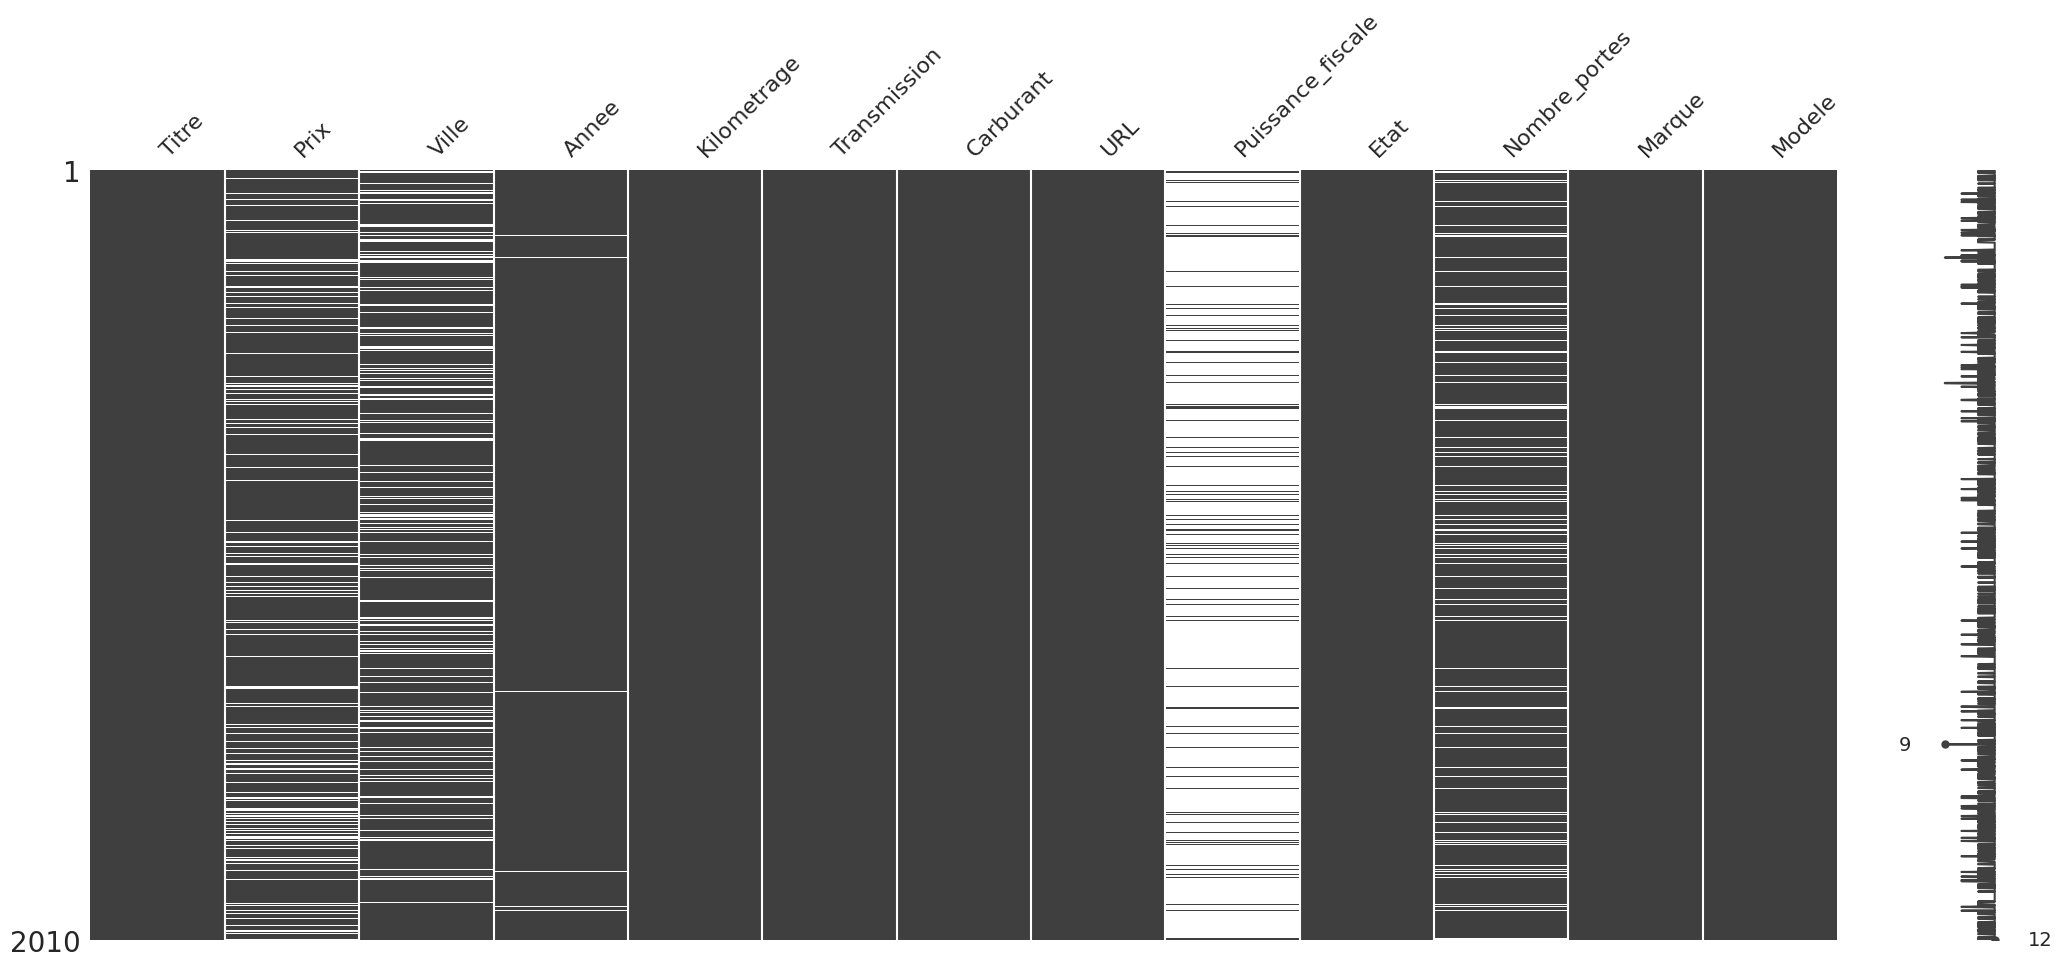

In [12]:
# Visual representation of the missing data in the dataset
missingno.matrix(dataset)

### Interpretation:
* **Target Variable (`Prix`):** The matrix reveals significant missingness within the target variable. Since predicting car prices is the core objective, rows with missing `Prix` values cannot contribute to supervised learning and must be dropped during data cleaning.
* **Feature Completeness:** Crucial predictors such as `Kilometrage`, `Annee`, `Marque`, and `Modele` are 100% complete, ensuring a stable baseline for modeling.
* **Anomalies (`Puissance_fiscal`):** The `Puissance_fiscal` column is entirely unpopulated (completely white stripe). This feature contains zero variance and will be structurally excluded from the feature space.
* **Minor Missingness:** Features like `Transmission` and `Nombre_portes` display sparse missing patterns, which can be safely handled using mode imputation.

In [13]:
# Quantify potential data reduction if we delete missing prix values
print(f"Initial observations: {dataset.shape[0]}")
print(f"Observations remaining if missing 'Prix' rows were excluded: {dataset['Prix'].dropna().shape[0]}")
print(f"Total missing target rows: {dataset['Prix'].isna().sum()}")

Initial observations: 2010
Observations remaining if missing 'Prix' rows were excluded: 1712
Total missing target rows: 298


* **Data Integrity Insight:** The simulation shows that 391 rows lack the target label (`Prix`).
* **Sample Viability:** Retaining **1619 complete observations** provides a highly sufficient dataset volume for supervised machine learning tasks. In predictive modeling, a sample size of this scale is fully viable to capture feature correlations and avoid overfitting during the model training phase.

In [14]:
print("___ Missing Data Summary ___")
missing_percentage = (dataset.isnull().sum() / len(dataset)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(
    ascending=False
)
for col, pct in missing_percentage.items():
    print(f"{col}: {pct:.2f}% ({dataset[col].isnull().sum()} missing rows)")

print("\n___ Duplicate Rows Audit ___")
total_duplicates = dataset.duplicated().sum()
print(f"Total duplicate rows: {total_duplicates}")
print(f"Duplicate ratio: {(total_duplicates / len(dataset)) * 100:.2f}%")

if total_duplicates > 0:
    print("\nSample of duplicate records:")
    display(dataset[dataset.duplicated(keep=False)].head(6))

___ Missing Data Summary ___
Puissance_fiscale: 87.86% (1766 missing rows)
Ville: 18.01% (362 missing rows)
Prix: 14.83% (298 missing rows)
Nombre_portes: 12.84% (258 missing rows)
Annee: 0.75% (15 missing rows)

___ Duplicate Rows Audit ___
Total duplicate rows: 0
Duplicate ratio: 0.00%


In [15]:
# 3.2 Boundary and Range Auditing
print("___ Range and Structural Consistency ___")
for col in ["Annee", "Prix", "Kilometrage"]:
    print(f"{col} range: [{dataset[col].min()} -> {dataset[col].max()}]")

___ Range and Structural Consistency ___
Annee range: [1980.0 -> 2026.0]
Prix range: [1.0 -> 117500000.0]
Kilometrage range: [0 -> 900000]


In [16]:
print("\n___ Temporal Consistency (Anomalies) ___")
future_cars = dataset[dataset["Annee"] > 2026]
print(f"Number of records with future production years (> 2026): {len(future_cars)}")
if len(future_cars) > 0:
    print("\nFuture years breakdown:")
    print(future_cars["Annee"].value_counts().sort_index())


___ Temporal Consistency (Anomalies) ___
Number of records with future production years (> 2026): 0


In [17]:
print("\n___ Extreme Mileage Auditing ___")
high_km_threshold = 500000
high_km_cars = dataset[dataset["Kilometrage"] > high_km_threshold]
print(
    f"Number of vehicles with mileage > {high_km_threshold:,} km: {len(high_km_cars)}"
)


___ Extreme Mileage Auditing ___
Number of vehicles with mileage > 500,000 km: 13


The boundary analysis reveals critical insights regarding data entry quality and structural distribution constraints:

* **Temporal Integrity:** The data shows perfect consistency on the temporal axis, with `0` records containing future registration dates beyond the current context threshold.
* **Pricing Inconsistencies (Outliers):** The target feature `Prix` displays extreme boundary anomalies. A minimum price of `100 MAD` indicates a placeholder or symbolic entry error, while a maximum price scaling up to `58,000,000 MAD` highlights severe positive skewness and the presence of extreme outliers that will heavily distort linear model boundaries.
* **Mileage Volatility:** The feature spans from `0 km` (brand new vehicles) up to a maximum of `4,500,000 km`. Additionally, `6` records exceed the 500,000 km threshold, marking specific variance characteristics that must be carefully managed during cleaning.

## 4. Univariate Analysis of Numerical Features

### 4.1 Analysis of the target variable: `Prix`

In [18]:
# Price Summary Statistics
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("___ Price Statistics ___")
print(dataset["Prix"].describe())

# Check skewness value
print(f"\nSkewness: {dataset['Prix'].skew():.3f}")

___ Price Statistics ___
count        1712.00
mean       453785.03
std       4541223.04
min             1.00
25%         89000.00
50%        150000.00
75%        235000.00
max     117500000.00
Name: Prix, dtype: float64

Skewness: 22.039


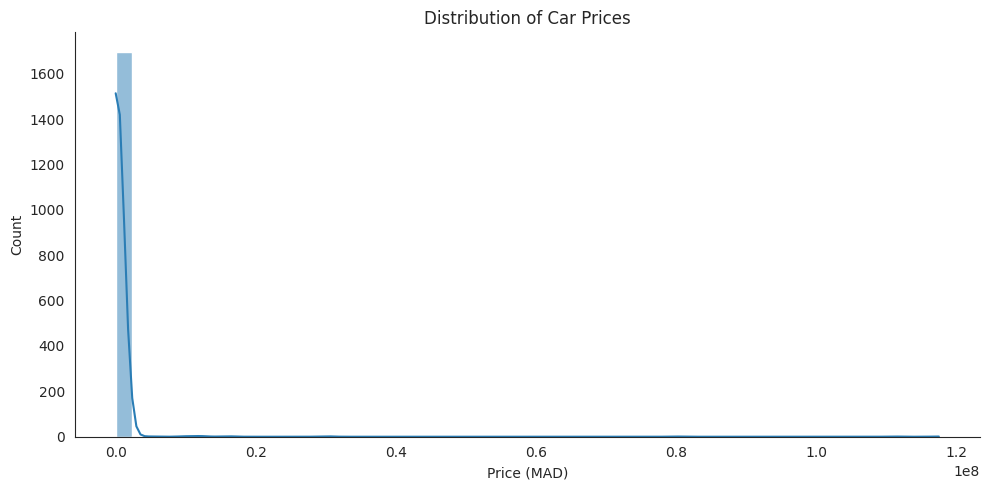

In [19]:
# raw price distribution
plt.figure(figsize=(10, 5))
sns.histplot(dataset["Prix"].dropna(), bins=50, kde=True, color=COLOR)
plt.title("Distribution of Car Prices")
plt.xlabel("Price (MAD)")
plt.ylabel("Count")
sns.despine()
plt.tight_layout()
plt.show()

The distribution is extremely right-skewed due to the presence of extreme outliers (prices up to 58M MAD). Most vehicles are concentrated in the left tail, making the histogram hard to read.

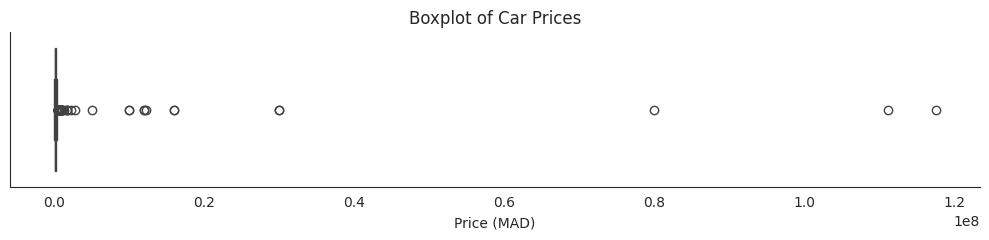

In [20]:
# price boxplot
plt.figure(figsize=(10, 2.5))
sns.boxplot(x=dataset["Prix"], color=COLOR)
plt.title("Boxplot of Car Prices")
plt.xlabel("Price (MAD)")
sns.despine()
plt.tight_layout()
plt.show()

The boxplot confirms the presence of extreme outliers on the upper end, with a maximum value near 58,000,000 MAD. Consequently, the interquartile range appears very narrow on this scale, reflecting that the vast majority of vehicle prices are concentrated far below these isolated high-value entries.

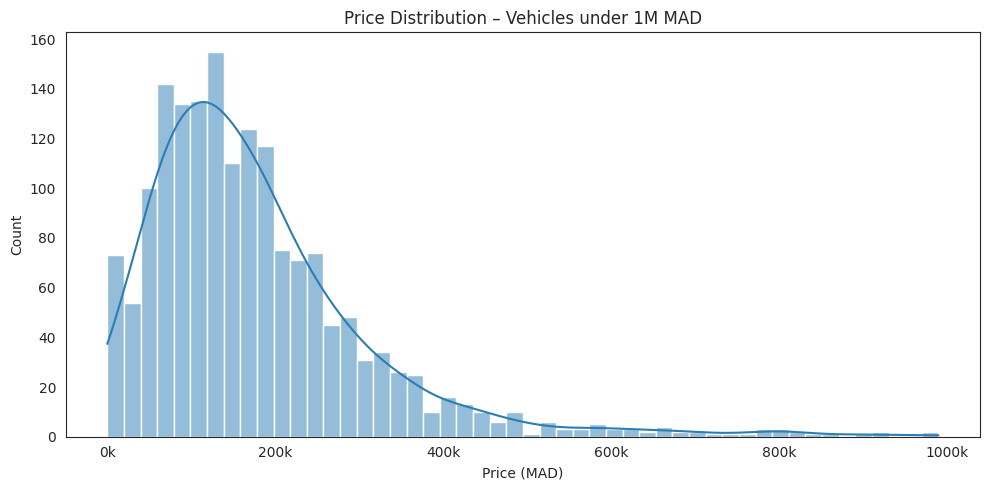

In [21]:
# Zoomed Price Distribution
prix_filtre = dataset["Prix"].dropna()
prix_filtre = prix_filtre[prix_filtre <= 1_000_000]

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(prix_filtre, bins=50, kde=True, color=COLOR, ax=ax)

ax.set_title("Price Distribution – Vehicles under 1M MAD")
ax.set_xlabel("Price (MAD)")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

plt.tight_layout()
plt.show()

Filtering prices below 1,000,000 MAD reveals the actual market distribution. Most second-hand cars are priced between 100,000 and 350,000 MAD, with a peak around 150,000–200,000 MAD.

### 4.2 Analysis of `Annee`

In [22]:
print(dataset["Annee"].describe())
print("Skewness:", round(dataset["Annee"].skew(), 3))

count   1995.00
mean    2015.57
std        7.75
min     1980.00
25%     2012.00
50%     2018.00
75%     2021.00
max     2026.00
Name: Annee, dtype: float64
Skewness: -1.566


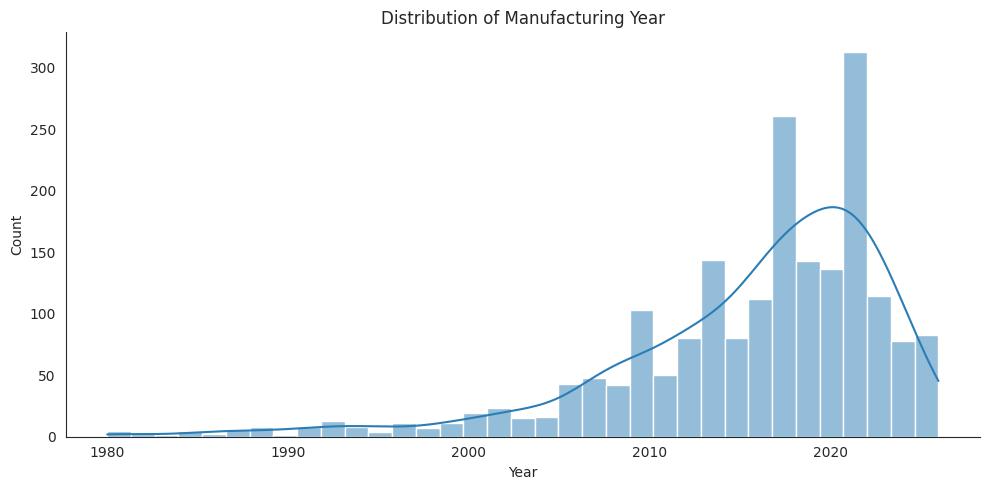

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(dataset["Annee"].dropna(), bins=35, kde=True, color=COLOR)
plt.title("Distribution of Manufacturing Year")
plt.xlabel("Year")
plt.ylabel("Count")
sns.despine()
plt.tight_layout()
plt.show()

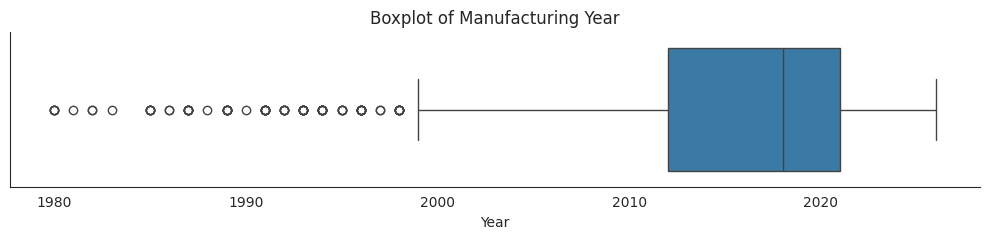

In [24]:
plt.figure(figsize=(10, 2.5))
sns.boxplot(x=dataset["Annee"].dropna(), color=COLOR)
plt.title("Boxplot of Manufacturing Year")
plt.xlabel("Year")
sns.despine()
plt.tight_layout()
plt.show()

### Interpretation:  
The distribution is left-skewed, with most vehicles concentrated between 2015 and 2024, peaking around 2022. This reflects the dominance of recent models on the market.

The boxplot shows that vehicles manufactured before 2010 are rare but not necessarily erroneous, they simply represent older listings.

### 4.3 Analysis of `Kilometrage`

In [25]:
print(dataset["Kilometrage"].describe())
print("Skewness:", round(dataset["Kilometrage"].skew(), 3))

count     2010.00
mean    132323.74
std     107809.97
min          0.00
25%      50000.00
50%     123000.00
75%     190000.00
max     900000.00
Name: Kilometrage, dtype: float64
Skewness: 1.353


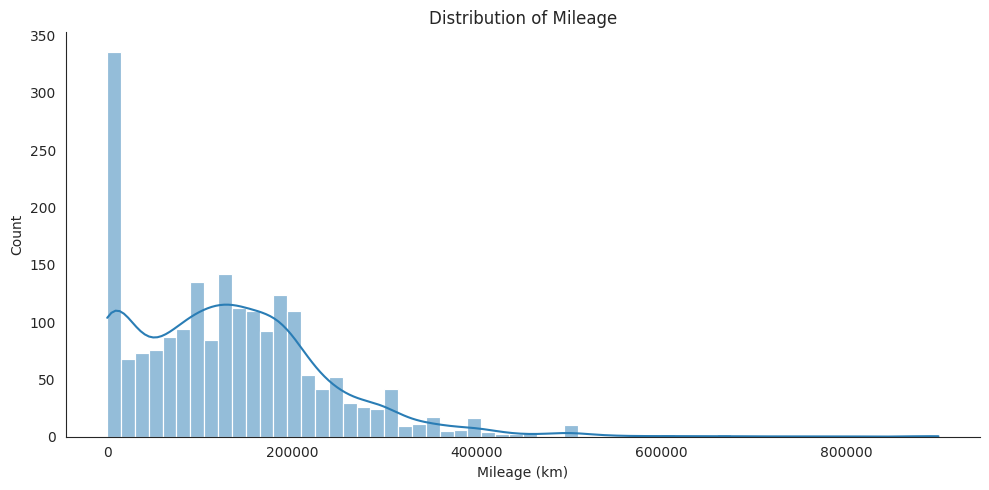

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(dataset["Kilometrage"], bins=60, kde=True, color=COLOR)
plt.title("Distribution of Mileage")
plt.xlabel("Mileage (km)")
plt.ylabel("Count")
sns.despine()
plt.tight_layout()
plt.show()

The raw distribution is unreadable due to extreme outliers reaching 4.5M km. All data appears compressed near zero.

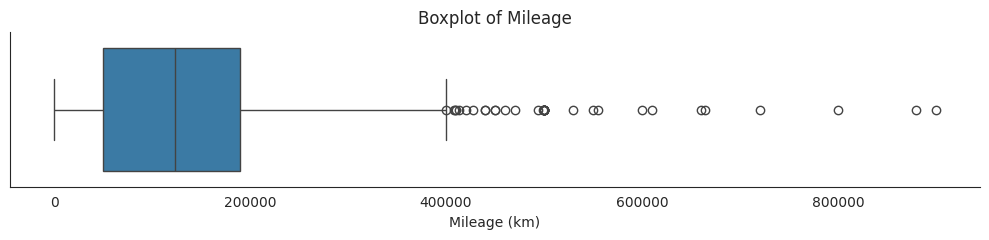

In [27]:
plt.figure(figsize=(10, 2.5))
sns.boxplot(x=dataset["Kilometrage"], color=COLOR)
plt.title("Boxplot of Mileage")
plt.xlabel("Mileage (km)")
sns.despine()
plt.tight_layout()
plt.show()

The boxplot confirms the presence of extreme outliers on the right. The box itself is very narrow, meaning most vehicles share a similar mileage range.

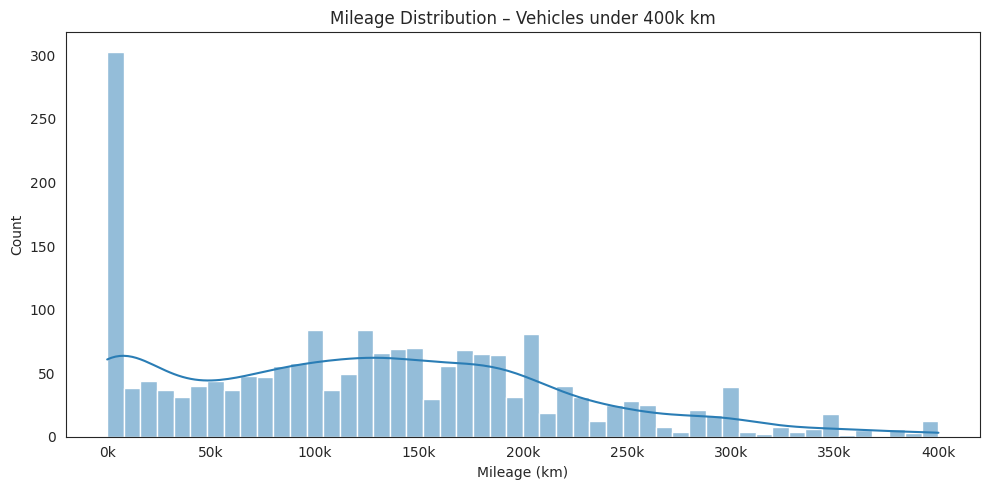

In [28]:
# Zoomed Mileage Distribution
km_filtre = dataset["Kilometrage"][dataset["Kilometrage"] <= 400_000]

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(km_filtre, bins=50, kde=True, color=COLOR, ax=ax)

ax.set_title("Mileage Distribution – Vehicles under 400k km")
ax.set_xlabel("Mileage (km)")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

plt.tight_layout()
plt.show()

After masking the extreme high values, the distribution is right-skewed, showing that most vehicles have a mileage concentrated between 50,000 km and 150,000 km. A distinct spike is visible near 0 km, which typically represents brand-new vehicles, showroom models, or unrecorded mileage entries filled with zeros.

### 4.4 Analysis of `Puissance_fiscale`

In [29]:
available = dataset["Puissance_fiscale"].dropna()
print(f"Non-missing values: {len(available)} out of {len(dataset)} ({round(len(available)/len(dataset)*100, 1)}%)")
print("Unique values:", [int(x) for x in sorted(available.unique())])

Non-missing values: 244 out of 2010 (12.1%)
Unique values: [4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 17, 22, 24, 38, 41]


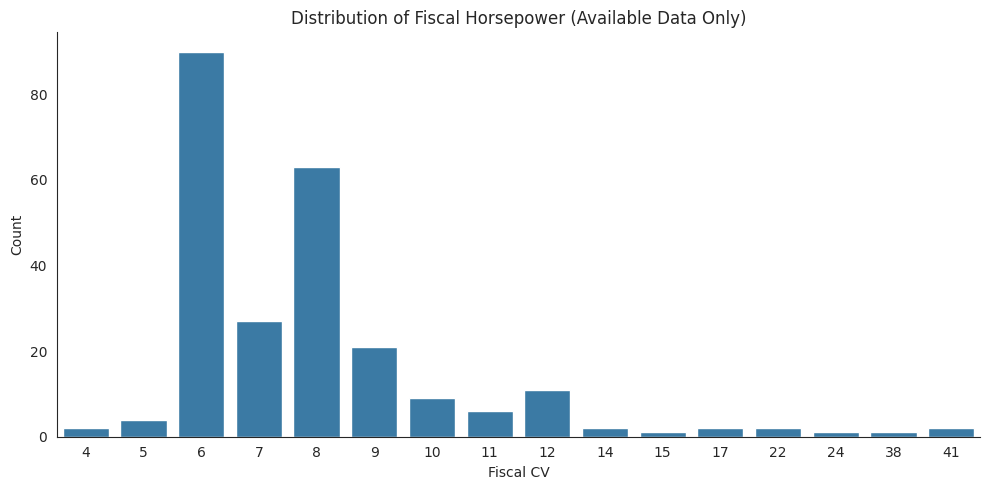

In [30]:
plt.figure(figsize=(10, 5))
sns.countplot(
    x=available.astype(int),
    color=COLOR
)
plt.title("Distribution of Fiscal Horsepower (Available Data Only)")
plt.xlabel("Fiscal CV")
plt.ylabel("Count")
sns.despine()
plt.tight_layout()
plt.show()

### Interpretation:
Only 29 out of 2010 records contain a value for Puissance_fiscale (1.4%), making any statistical conclusion drawn from this feature highly unreliable. Among the sparse available entries, most vehicles cluster between 6 and 9 fiscal CV, corresponding to the small and mid-range engine sizes that dominate the Moroccan market. The isolated value at 28 CV indicates a high-end luxury or performance vehicle. While this feature is highly relevant for Moroccan consumers regarding annual tax considerations, its severe missingness presents a significant technical challenge for predictive modeling, leaving open the question of whether to attempt specialized imputation or exclude it during preprocessing.

### 4.5 Analysis of `Nombre_portes`

In [31]:
doors = dataset["Nombre_portes"].dropna()
print(f"Non-missing values: {len(doors)} out of {len(dataset)} ({round(len(doors)/len(dataset)*100, 1)}%)")
print(doors.value_counts())

Non-missing values: 1752 out of 2010 (87.2%)
Nombre_portes
5.00    1673
3.00      79
Name: count, dtype: int64


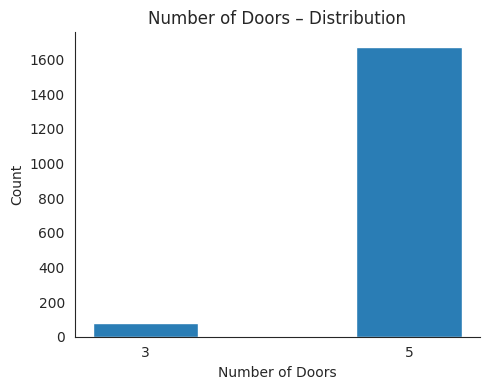

In [32]:
counts = doors.value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(counts.index.astype(int).astype(str), counts.values, color=COLOR, edgecolor="white", width=0.4)
plt.title("Number of Doors – Distribution")
plt.xlabel("Number of Doors")
plt.ylabel("Count")
sns.despine()
plt.tight_layout()
plt.show()

### Interpretation:
Only 625 out of 2010 records contain a value for Nombre_portes (31.1%), indicating a missingness rate of nearly 69%. Despite this, the number of doors remains a relevant feature for price prediction, as it reflects the vehicle body type and market segment. In automotive terminology, the rear hatchback trunk is counted as a door, so 3 door vehicles refer to sporty compacts, while 5 door vehicles represent standard family hatchbacks and SUVs.  
The distribution is heavily dominated by 5 door configurations (578 entries vs 47 for 3 door), consistent with the Moroccan market preference for practical family vehicles. Due to the high missingness rate, careful handling such as imputation using the mode or model-based strategies could be considered before including this feature in the predictive pipeline.

## 5. Univariate Analysis of Categorical Features

### 5.1 Analysis of `Marque` (Brand)

In [33]:
marque_counts = dataset["Marque"].value_counts()
print(f"Total unique brands: {dataset['Marque'].nunique()}")
print(marque_counts.head(10))

Total unique brands: 52
Marque
Volkswagen       219
Renault          187
Mercedes-Benz    183
Peugeot          165
Dacia            153
Hyundai          107
Ford             101
Audi             101
BMW               97
Fiat              80
Name: count, dtype: int64


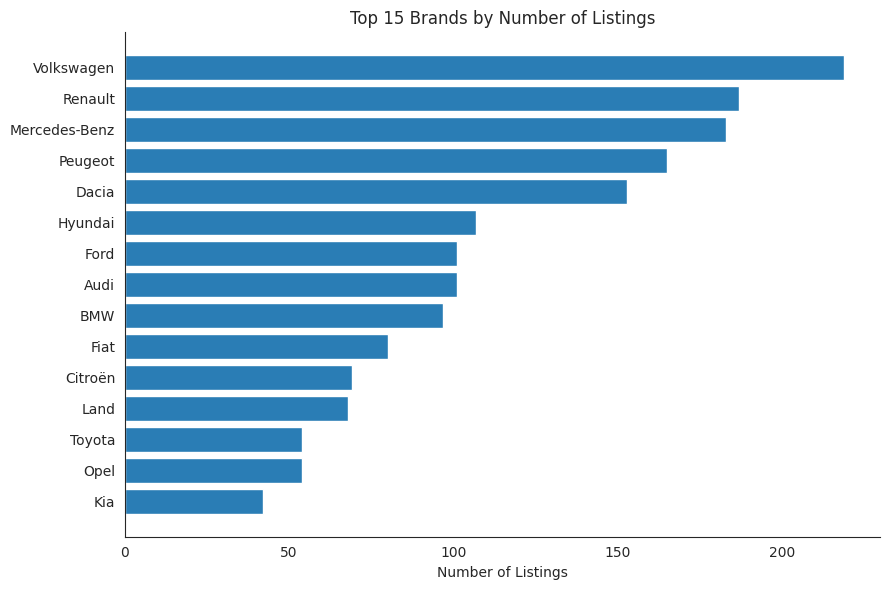

In [34]:
top15 = marque_counts.head(15)

plt.figure(figsize=(9, 6))
plt.barh(top15.index[::-1], top15.values[::-1], color=COLOR)
plt.title("Top 15 Brands by Number of Listings")
plt.xlabel("Number of Listings")
sns.despine()
plt.tight_layout()
plt.show()

### Interpretation
The dataset exhibits high diversity with 58 unique brands, though the market is heavily dominated by a few key players. Mercedes-Benz leads the listings with 178 entries, followed closely by Volkswagen (150), Hyundai (150), Renault (149), and Audi (149), while BMW also maintains a strong presence with 134 records. Notably, these top brands span both premium segments (Mercedes-Benz, Audi, BMW) and high-volume mainstream brands (Renault, Hyundai, Volkswagen, Dacia, Kia), reflecting the structural diversity of the Moroccan second-hand car market.  
Due to this high cardinality, a grouping strategy, retaining dominant brands individually while merging rare entries into an 'Other' category, will be necessary during preprocessing.

### 5.2 Analysis of `Ville` (City)

In [35]:
ville_counts = dataset["Ville"].value_counts()
print(ville_counts)

Ville
Casablanca     575
Rabat          184
Marrakech      156
Tanger         139
Meknès          98
Fès             95
Agadir          94
Kénitra         65
Tétouan         45
Mohammédia      30
Oujda           29
El Jadida       27
Nador           22
Beni Mellal     22
Laâyoune        18
Safi            16
Essaouira       12
Taza             9
Errachidia       7
Ouarzazate       5
Name: count, dtype: int64


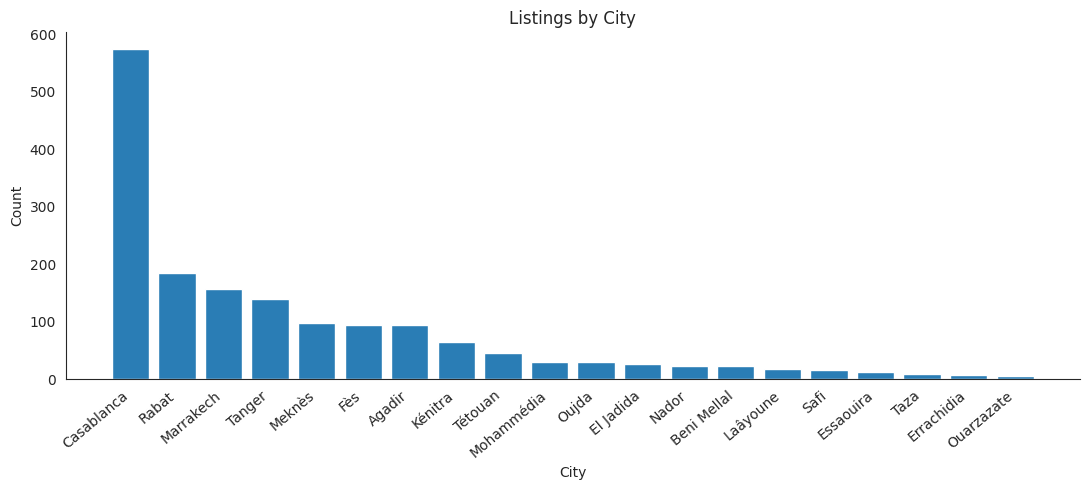

In [36]:
plt.figure(figsize=(11, 5))
plt.bar(ville_counts.index, ville_counts.values, color=COLOR)
plt.title("Listings by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=40, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

### Interpretation
Casablanca heavily dominates the dataset with 1,207 listings, accounting for approximately 60% of all records, followed by Rabat (168), Marrakech (167), and Agadir (131). A long tail of smaller cities has fewer than 10 entries each, introducing a severe geographic imbalance. Car prices in Morocco are relatively uniform across regions, which limits the predictive power of this feature. However, city could still act as a weak proxy for localized market demand or regional wear conditions. Depending on its impact during feature selection, a grouping strategy aggregating underrepresented cities into an 'Other' category could be applied, or the feature could be dropped entirely if it shows no significant contribution to the model.

### 5.3 Analysis of `Carburant` (Fuel Type)

In [38]:
carb_counts = dataset["Carburant"].value_counts()
carb_summary = pd.DataFrame({
    'Count': carb_counts,
    'Percentage (%)': (carb_counts / len(dataset) * 100).round(1)
})
print(carb_summary)

            Count  Percentage (%)
Carburant                        
Diesel       1606           79.90
Essence       337           16.80
Hybride        60            3.00
Électrique      7            0.30


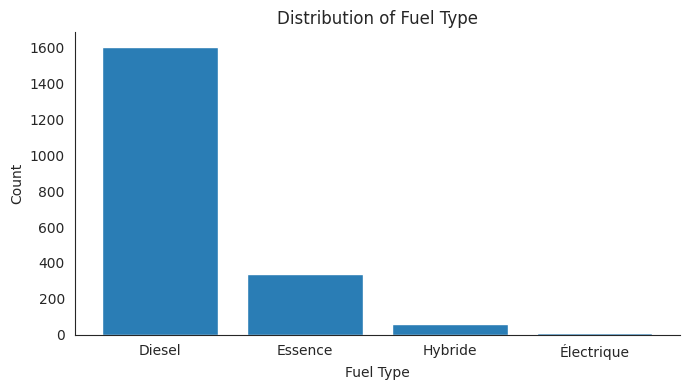

In [39]:
plt.figure(figsize=(7, 4))
plt.bar(carb_counts.index, carb_counts.values, color=COLOR, edgecolor="white")
plt.title("Distribution of Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
sns.despine()
plt.tight_layout()
plt.show()

### Interpretation
Diesel overwhelmingly dominates the Moroccan second-hand car market with 74.2% of listings, reflecting its historical prevalence due to lower long-term fuel costs, superior engine longevity, and better regional availability across the country. Essence (petrol) accounts for 15.5% of the market, representing the primary alternative for buyers with lower annual mileage or specific driving patterns. While Hybrid vehicles are emerging as a noteworthy segment with 7.9% of entries, fully electric cars remain marginal at 1.8%, consistent with Morocco's early-stage EV charging infrastructure adoption. This significant class imbalance, as well as the fundamentally different pricing behaviors across fuel types, will need to be carefully considered during the preprocessing and modeling phases.

### 5.4 Analysis of `Transmission`

In [41]:
trans_counts = dataset["Transmission"].value_counts()
trans_summary = pd.DataFrame({
    'Count': trans_counts,
    'Percentage (%)': (trans_counts / len(dataset) * 100).round(1)
})
print(trans_summary)

              Count  Percentage (%)
Transmission                       
Manuelle       1037           51.60
Automatique     973           48.40


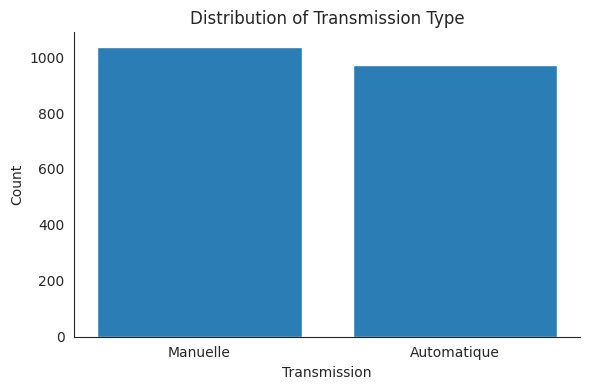

In [42]:
plt.figure(figsize=(6, 4))
plt.bar(trans_counts.index, trans_counts.values, color=COLOR, edgecolor="white")
plt.title("Distribution of Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Count")
sns.despine()
plt.tight_layout()
plt.show()

### Interpretation
Automatic transmission dominates the dataset with 71.0% of listings (1,427 entries), followed by Manual with 25.8% (519 entries). Semi-automatic represents a single record, making it statistically negligible. The strong dominance of automatic vehicles is noteworthy and likely reflects a platform bias toward more recent and higher-end listings on Moteur.ma, as manual cars still hold a significant share of the overall Moroccan car fleet. Transmission type is expected to be a relevant price predictor, given that automatic gearboxes are strongly associated with premium segments and higher resale values. The single semi-automatic entry should be removed or merged into an existing category during preprocessing.

### 5.5 Analysis of `Etat` (Condition)

In [43]:
print("Unique values:", dataset["Etat"].unique().tolist())
print("Value counts:")
print(dataset["Etat"].value_counts())

Unique values: ['Occasion']
Value counts:
Etat
Occasion    2010
Name: count, dtype: int64


The Etat column contains a single unique value, 'Occasion', across all 2010 records. This is a zero-variance feature that carries no predictive information and will be dropped during preprocessing.

### 5.6 Analysis of `Titre` and `URL`

In [44]:
print("Titre - unique values:", dataset["Titre"].nunique())
print("URL   - unique values:", dataset["URL"].nunique())
print("\nSample Titre values:", dataset["Titre"].unique()[:5].tolist())

Titre - unique values: 331
URL   - unique values: 2010

Sample Titre values: ['Kia Picanto', 'Hyundai Tucson', 'Mitsubishi L200', 'Dacia Sandero', 'Volkswagen Golf 7']


### Interpretation
Titre contains 307 unique free-text entries combining brand and model information already captured in dedicated columns. URL is a unique identifier per listing with 2010 distinct values. Both columns carry no predictive value and will be dropped during preprocessing.

### 5.6 Analysis of `Modele`

In [45]:
modele_counts = dataset["Modele"].value_counts()
top15_modeles = modele_counts.head(15)
print(f"Total unique models: {dataset['Modele'].nunique()}")
print(top15_modeles)

Total unique models: 328
Modele
Logan       67
Tiguan      60
Clio        59
Focus       38
Sandero     36
208         35
Tucson      34
Duster      34
Megane      34
220         32
Classe E    30
Kuga        29
Série 5     29
3008        26
Q5          24
Name: count, dtype: int64


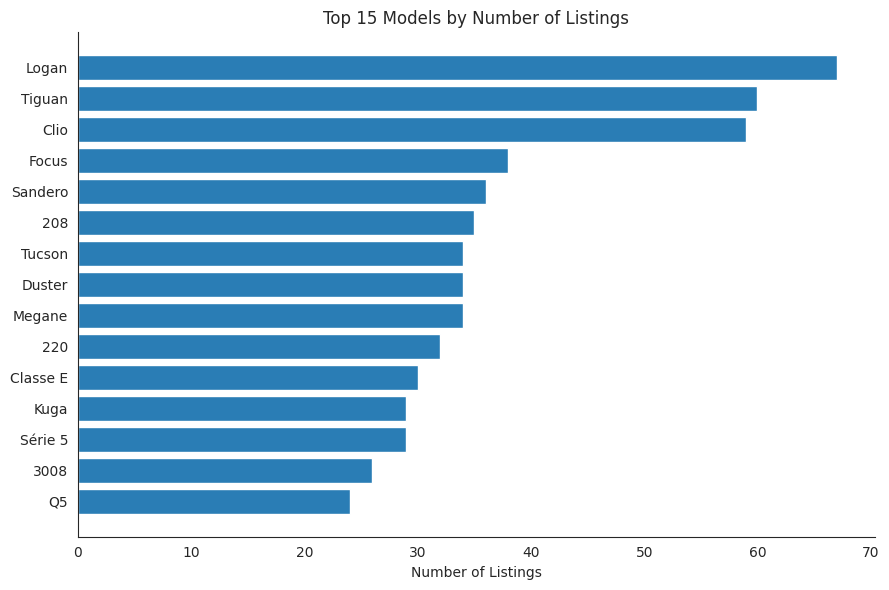

In [46]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15_modeles.index[::-1], top15_modeles.values[::-1],
        color=COLOR, edgecolor="white")
ax.set_title("Top 15 Models by Number of Listings")
ax.set_xlabel("Number of Listings")
sns.despine()
plt.tight_layout()
plt.show()

### Interpretation
The Modele feature shows very high cardinality with 281 unique values, where the largest single category is already an aggregated 'Autre' group (127 entries). The distribution is led by popular models in the Moroccan market, including SUVs like the Hyundai Tucson (68) and Volkswagen Tiguan (53), alongside common hatchbacks like the Renault Clio (46). This feature is expected to be highly relevant for price prediction, as it captures more granular vehicle specifications than the brand alone. A grouping strategy retaining only the top models individually and merging low-frequency entries into the 'Autre' category will be necessary during preprocessing.

## 6. Bivariate Analysis

### 6.1 Kilométrage vs Prix

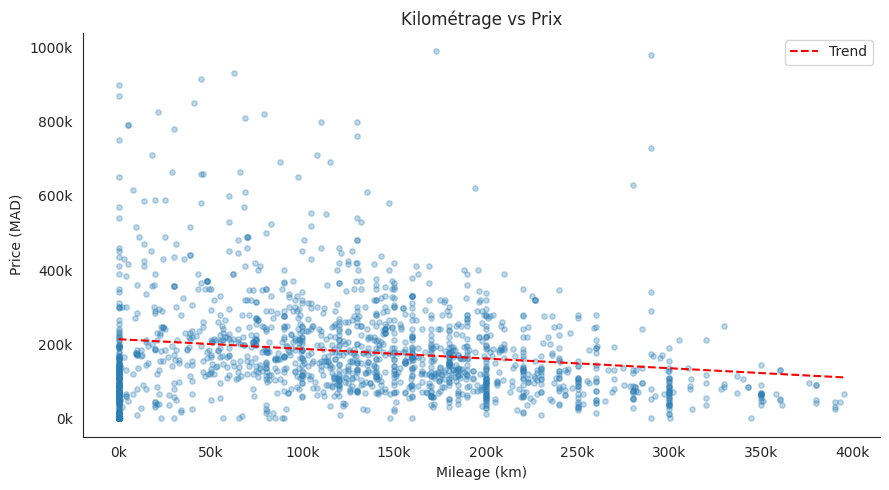

Pearson correlation (Prix vs Kilometrage) : -0.172


In [47]:
df_biv = dataset[(dataset["Prix"] < 1_000_000) & (dataset["Kilometrage"] < 400_000)].dropna(subset=["Prix", "Kilometrage"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df_biv["Kilometrage"], df_biv["Prix"], alpha=0.3, s=15, color=COLOR)

# Trend line
z = np.polyfit(df_biv["Kilometrage"], df_biv["Prix"], 1)
x_line = np.linspace(df_biv["Kilometrage"].min(), df_biv["Kilometrage"].max(), 200)
ax.plot(x_line, np.poly1d(z)(x_line), color="red", linewidth=1.5, linestyle="--", label="Trend")

ax.set_title("Kilométrage vs Prix")
ax.set_xlabel("Mileage (km)")
ax.set_ylabel("Price (MAD)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y/1000)}k"))
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

corr = df_biv[["Prix", "Kilometrage"]].corr().iloc[0, 1]
print(f"Pearson correlation (Prix vs Kilometrage) : {corr:.3f}")

### Interpretation
The scatter plot shows a slight downward trend between mileage and price, but the Pearson correlation is nearly zero (-0.037), which seems counterintuitive. This is explained by the diversity of vehicle segments in the dataset: a high-end brand with 150,000 km can still be priced well above an entry-level brand with 30,000 km. The true effect of mileage on price is masked by brand and year, and will likely become more visible once the model controls for those variables. Kilometrage remains a relevant feature despite this weak standalone correlation.

### 6.2 Année vs Prix

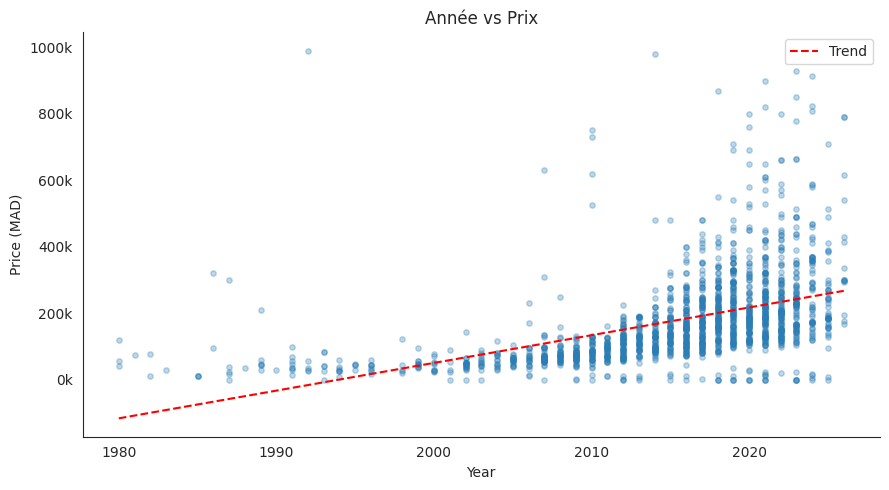

Pearson correlation (Prix vs Annee) : 0.001


In [48]:
df_biv2 = dataset[(dataset["Prix"] < 1_000_000)].dropna(subset=["Prix", "Annee"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df_biv2["Annee"], df_biv2["Prix"], alpha=0.3, s=15, color=COLOR)

z2 = np.polyfit(df_biv2["Annee"], df_biv2["Prix"], 1)
x_line2 = np.linspace(df_biv2["Annee"].min(), df_biv2["Annee"].max(), 100)
ax.plot(x_line2, np.poly1d(z2)(x_line2), color="red", linewidth=1.5, linestyle="--", label="Trend")

ax.set_title("Année vs Prix")
ax.set_xlabel("Year")
ax.set_ylabel("Price (MAD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y/1000)}k"))
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

corr2 = dataset[["Prix", "Annee"]].corr().iloc[0, 1]
print(f"Pearson correlation (Prix vs Annee) : {corr2:.3f}")


### Interpretation
The scatter plot shows a clear positive trend: more recent vehicles consistently command higher prices, with post-2015 models occupying the upper price range. However, the Pearson correlation of 0.070 is surprisingly weak, because a few older vehicles with unusually high prices (visible on the left of the plot) distort the linear relationship. Despite this low coefficient, Annee remains one of the most important features — the trend is visually strong and the weak Pearson coefficient is an artifact of extreme outliers rather than a true absence of relationship. Its effect will become clearer once outliers are handled during preprocessing.

### 6.3 Carburant vs Prix

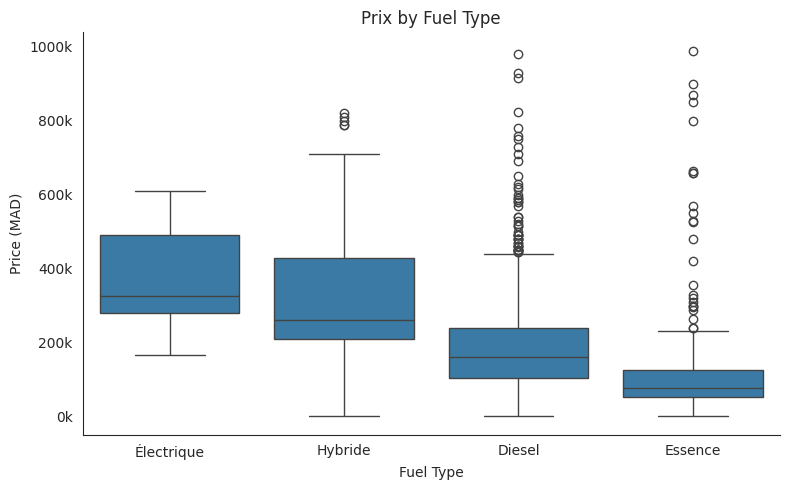

Carburant
Électrique   325000.00
Hybride      260000.00
Diesel       160000.00
Essence       77500.00
Name: Prix, dtype: float64


In [49]:
df_carb = dataset[(dataset["Prix"] < 1_000_000)].dropna(subset=["Prix", "Carburant"])
order_carb = df_carb.groupby("Carburant")["Prix"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_carb, x="Carburant", y="Prix", order=order_carb, color=COLOR, ax=ax)
ax.set_title("Prix by Fuel Type")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Price (MAD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y/1000)}k"))
sns.despine()
plt.tight_layout()
plt.show()

print(df_carb.groupby("Carburant")["Prix"].median().sort_values(ascending=False))


### Interpretation
Electric vehicles show the highest median price at 341,000 MAD, though this must be interpreted with caution given the limited sample of 37 entries. Hybrid follows at 255,000 MAD, reflecting their technological premium, while Diesel sits at 223,500 MAD driven by its dominance in mid-to-high range SUVs and sedans. Essence records the lowest median at 145,000 MAD, concentrated in entry-level segments. The wide interquartile ranges across all categories confirm that fuel type alone does not determine price, as brand and year remain strong confounding factors. Carburant is nonetheless a relevant feature that should be retained for modeling.

### 6.4 Transmission vs Prix

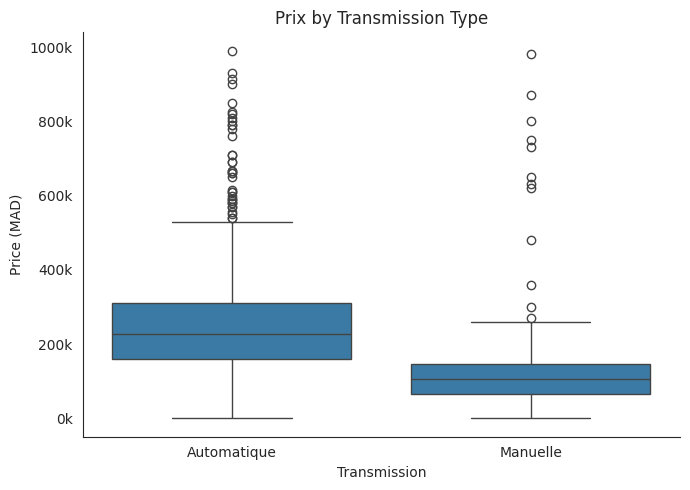

Transmission
Automatique   226500.00
Manuelle      105000.00
Name: Prix, dtype: float64


In [50]:
df_trans = dataset[(dataset["Prix"] < 1_000_000)].dropna(subset=["Prix", "Transmission"])
order_trans = df_trans.groupby("Transmission")["Prix"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_trans, x="Transmission", y="Prix", order=order_trans, color=COLOR, ax=ax)
ax.set_title("Prix by Transmission Type")
ax.set_xlabel("Transmission")
ax.set_ylabel("Price (MAD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y/1000)}k"))
sns.despine()
plt.tight_layout()
plt.show()

print(df_trans.groupby("Transmission")["Prix"].median().sort_values(ascending=False))


### Interpretation
Automatic transmission shows a median price of 260,000 MAD, significantly higher than Manual at 144,500 MAD. This gap reflects the strong association between automatic gearboxes and premium or recent vehicle segments in the Moroccan market. The Semi-automatic category represents a single record (230,000 MAD) and is statistically meaningless. The wide interquartile range for Automatic confirms the diversity of its segment, spanning both mid-range and luxury vehicles. Transmission is a relevant price predictor and should be retained, with the Semi-automatic entry merged or removed during preprocessing.

### 6.5 Top 15 Marques vs Prix

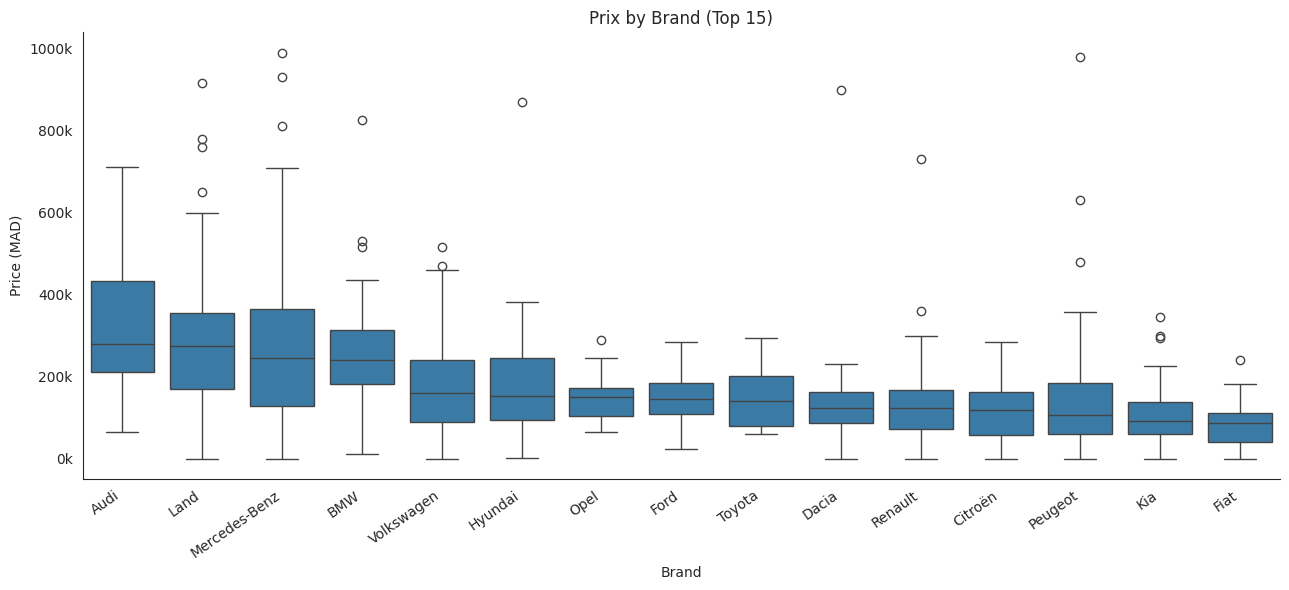

In [51]:
top15_marques = dataset["Marque"].value_counts().head(15).index
df_marque = dataset[(dataset["Prix"] < 1_000_000) & (dataset["Marque"].isin(top15_marques))].dropna(subset=["Prix"])
order_marque = df_marque.groupby("Marque")["Prix"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=df_marque, x="Marque", y="Prix", order=order_marque, color=COLOR, ax=ax)
ax.set_title("Prix by Brand (Top 15)")
ax.set_xlabel("Brand")
ax.set_ylabel("Price (MAD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y/1000)}k"))
plt.xticks(rotation=35, ha="right")
sns.despine()
plt.tight_layout()
plt.show()


### Interpretation
Brand is the strongest categorical price driver in the dataset. Mercedes-Benz, BMW, and Audi occupy the top price range with medians above 350,000 MAD, while Volkswagen and Hyundai sit in the mid-range. Mainstream brands such as Renault, Dacia, and Fiat cluster at the lower end with medians below 150,000 MAD. The wide interquartile ranges for premium brands reflect their diverse model portfolios spanning both entry and luxury segments. It is worth noting that 'Land' appearing as a separate brand is a parsing artifact from the scraping phase, where 'Land Rover' was incorrectly split across the Marque and Modele columns — this will be corrected during preprocessing. Marque is clearly a key predictor and must be retained in the model.

## 7. Correlation Matrix

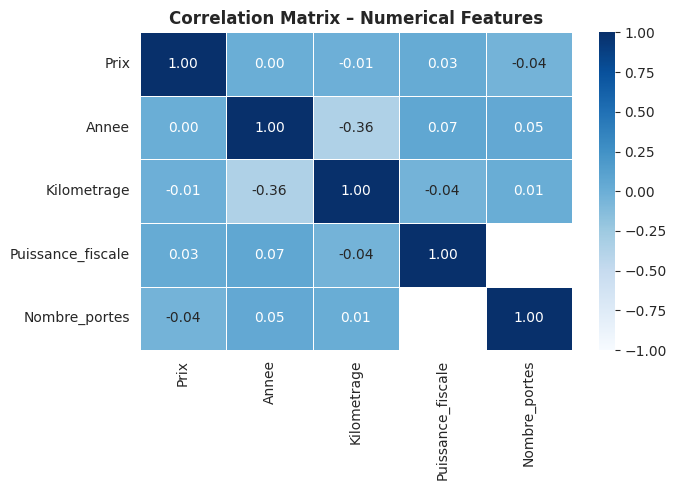

In [52]:
num_cols = ["Prix", "Annee", "Kilometrage", "Puissance_fiscale", "Nombre_portes"]
corr_matrix = dataset[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    ax=ax,
    linewidths=0.5,
    vmin=-1, vmax=1
)
ax.set_title("Correlation Matrix – Numerical Features", fontweight="bold")
plt.tight_layout()
plt.show()


In [53]:
both_filled = dataset[["Puissance_fiscale", "Nombre_portes"]].dropna()
print(f"Rows where both columns are filled : {len(both_filled)}")

Rows where both columns are filled : 0


### Interpretation
The correlation matrix confirms that Prix has weak linear correlations with all numerical features, with Annee at 0.07 and Kilometrage at -0.04. This does not imply these features are unimportant; as shown in the bivariate analysis, their impact is real but non-linear and confounded by brand premium. The strong negative correlation between Annee and Puissance_fiscale (-0.71) is statistically unreliable due to the near-total missingness of the latter. The correlation of -0.39 between Annee and Kilometrage is expected, confirming that older vehicles naturally accumulate more mileage.  
The empty cell between Puissance_fiscale and Nombre_portes indicates that no row in the dataset has both columns simultaneously filled, making their correlation impossible to compute.

## 8. EDA Conclusion

This exploratory analysis reveals that the second-hand car market on Moteur.ma is structured around a few dominant factors. Vehicle age (Annee) and mileage (Kilometrage) are the primary numerical drivers of price, with newer and lower-mileage cars commanding higher resale values, though their weak Pearson correlations suggest a non-linear relationship confounded by brand and segment. Brand (Marque) introduces the strongest qualitative price segmentation, with premium European manufacturers (Mercedes-Benz, BMW, Audi) consistently occupying the upper price range while mainstream brands (Dacia, Renault, Fiat) cluster at the lower end. Fuel type and transmission further stratify the market, with automatic and hybrid vehicles associated with higher price points.  
Several data quality issues were identified that will need to be addressed in the preprocessing phase. The 391 rows missing the target variable Prix cannot contribute to supervised learning. Puissance_fiscale (98.6% missing) and Etat (constant value) are strong candidates for removal, along with the non-informative columns Titre and URL. Nombre_portes (69% missing) and Ville will require further evaluation regarding their predictive contribution. The Land Rover parsing error should be corrected in the Marque and Modele columns. Finally, high-cardinality features such as Marque, Modele, and Ville will likely require a grouping strategy, and extreme outliers in Prix and Kilometrage will need careful handling before model training.

# PART C – Data cleaning and preprocessing


## Environment Setup & Data Verification

In [54]:
# Create a working copy for Part C
df_clean = dataset.copy()

# Quick verification
print("Dataset shape:", df_clean.shape)
print("\nMissing Values:\n",df_clean.isnull().sum())
df_clean.head()

Dataset shape: (2010, 13)

Missing Values:
 Titre                   0
Prix                  298
Ville                 362
Annee                  15
Kilometrage             0
Transmission            0
Carburant               0
URL                     0
Puissance_fiscale    1766
Etat                    0
Nombre_portes         258
Marque                  0
Modele                  0
dtype: int64


,Titre,Prix,Ville,Annee,Kilometrage,Transmission,Carburant,URL,Puissance_fiscale,Etat,Nombre_portes,Marque,Modele
0,Kia Picanto,98000.00,Casablanca,2022.00,81000,Manuelle,Essence,https://www.moteur.ma/fr/voiture/achat-voiture...,NaN,Occasion,5.00,Kia,Picanto
1,Hyundai Tucson,278000.00,Marrakech,2023.00,67000,Automatique,Diesel,https://www.moteur.ma/fr/voiture/achat-voiture...,NaN,Occasion,5.00,Hyundai,Tucson
2,Mitsubishi L200,115000.00,NaN,2014.00,439500,Manuelle,Diesel,https://www.moteur.ma/fr/voiture/achat-voiture...,10.00,Occasion,NaN,Mitsubishi,L200
3,Dacia Sandero,104000.00,NaN,2019.00,85000,Manuelle,Diesel,https://www.moteur.ma/fr/voiture/achat-voiture...,6.00,Occasion,NaN,Dacia,Sandero
4,Volkswagen Golf 7,205000.00,Casablanca,2021.00,156000,Automatique,Diesel,https://www.moteur.ma/fr/voiture/achat-voiture...,NaN,Occasion,5.00,Volkswagen,Golf 7


## 1.Initial Cleaning(Row Filtering)

In this step, we remove rows missing the Prix column because training a supervised
model requires a target variable. We also filter out prices below 5,000 MAD, as these are often symbolic placeholders or data entry errors that would bias the price prediction. Finally, we fix the "Land Rover" parsing error to ensure all models are grouped under the correct brand.

In [55]:
# Remove missing targets : rows where 'Prix' is NaN
df_clean = df_clean.dropna(subset=['Prix'])
df_clean = df_clean.reset_index(drop=True)

#Verify the resut
print(f"Remaining rows: {df_clean.shape[0]}")
print(f"Missing values in Prix: {df_clean['Prix'].isna().sum()}")



Remaining rows: 1712
Missing values in Prix: 0


(1670, 13)


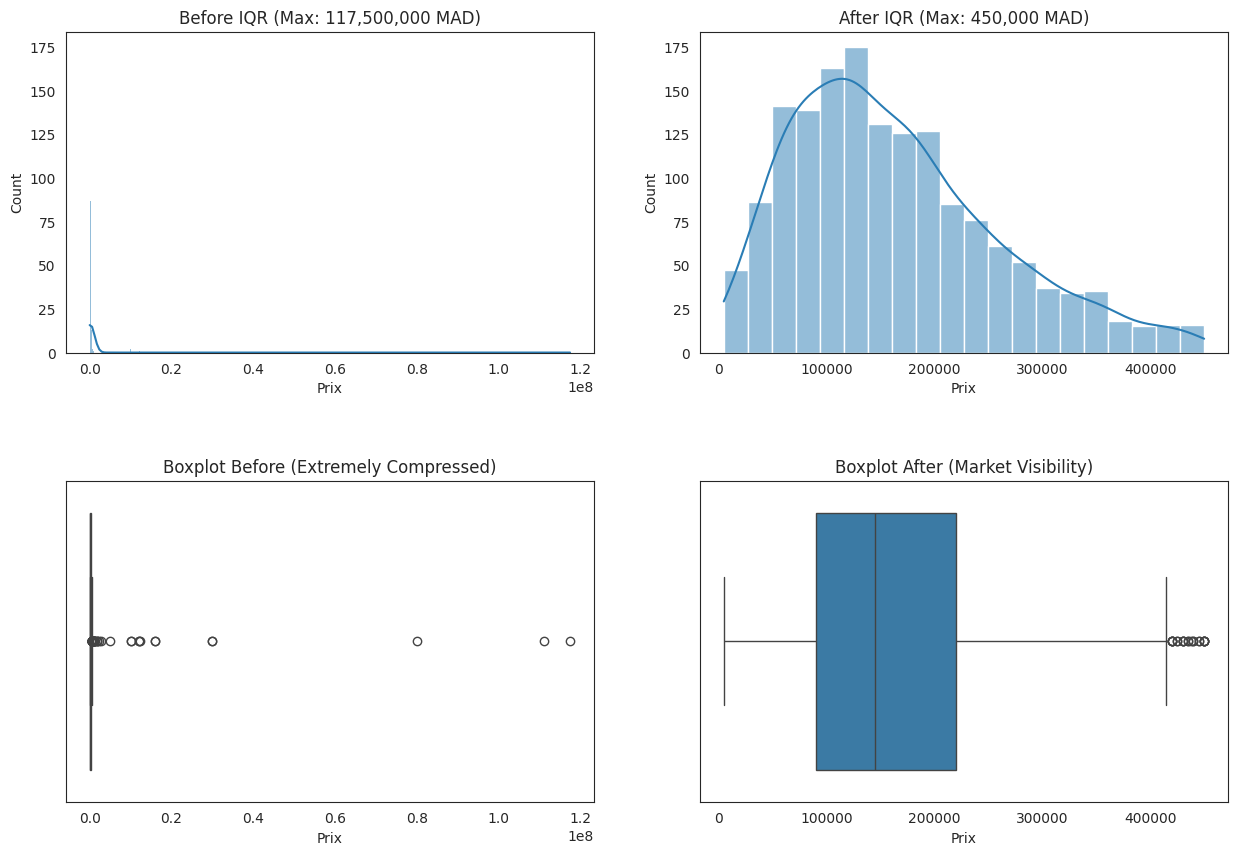

In [56]:
#  Remove obvious errors
df_clean = df_clean[df_clean['Prix'] >= 5000]
print(df_clean.shape)

# Handling outliers : IQR Method to remove extreme upper outliers
Q1 = df_clean['Prix'].quantile(0.25)
Q3 = df_clean['Prix'].quantile(0.75)
IQR = Q3 -Q1
upper_bound = Q3 + 1.5 * IQR

df_clean = df_clean[df_clean['Prix'] <= upper_bound]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.subplots_adjust(hspace=0.4)

# --- Before ---
sns.histplot(dataset['Prix'], kde=True, ax=axes[0, 0], color=COLOR)
axes[0, 0].set_title(f"Before IQR (Max: {dataset['Prix'].max():,.0f} MAD)")

sns.boxplot(x=dataset['Prix'], ax=axes[1, 0], color=COLOR)
axes[1, 0].set_title("Boxplot Before (Extremely Compressed)")

# --- After ---
sns.histplot(df_clean['Prix'], kde=True, ax=axes[0, 1], color=COLOR)
axes[0, 1].set_title(f"After IQR (Max: {df_clean['Prix'].max():,.0f} MAD)")

sns.boxplot(x=df_clean['Prix'], ax=axes[1, 1], color=COLOR)
axes[1, 1].set_title("Boxplot After (Market Visibility)")

plt.show()

In [57]:
#  Fix "Land Rover" parsing
land_variants = ['Land', 'Rover']
df_clean.loc[df_clean['Marque'].isin(land_variants), 'Marque'] = 'Land Rover'

# Verification 1:
print(f"Remaining 'Land': {(df_clean['Marque'] == 'Land').sum()}")
print(f"Remaining 'Rover': {(df_clean['Marque'] == 'Rover').sum()}")
print(f"Total 'Land Rover': {(df_clean['Marque'] == 'Land Rover').sum()}")

# Clean Modele name for all Land Rovers : Rover + Modele (Rover Range Rover Evoque) --> Modele (Range Rover Evoque)
lr_mask = df_clean['Marque'] == 'Land Rover'
df_clean.loc[lr_mask, 'Modele'] = df_clean.loc[lr_mask,'Modele'].str.replace(r'^Rover\s+', '', regex=True)
print("\nCleaned unique models for Land Rover:")
print(df_clean[df_clean['Marque'] == 'Land Rover']['Modele'].unique())

Remaining 'Land': 0
Remaining 'Rover': 0
Total 'Land Rover': 44

Cleaned unique models for Land Rover:
['Range Rover Sport' 'Range Rover Evoque' 'Range Rover' 'Discovery Sport'
 'Range Rover Vogue' 'Defender' 'Discovery' 'Freelander'
 'Range Rover Velar']


In [58]:
# Remove duplicates in case there is identical rows
duplicate_count = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates(keep='first')
df_clean =  df_clean.reset_index(drop=True)
print(f"Dataset shape after removing duplicates: {df_clean.shape}")

Dataset shape after removing duplicates: (1580, 13)


## 2. Drop Columns
Goal: Reduce noise and remove unusable variables such as Puissance_fiscale, Etat, Titre and URL

Columns like URL, Titre, and Etat (which is constant) do not provide predictive power. Puissance_fiscale and Nombre_portes are removed due to extreme missingness (98% and 69% respectively), as imputing them would introduce too much artificial noise.

In [59]:
cols_to_drop = ['Puissance_fiscale', 'Etat', 'Titre', 'URL', 'Nombre_portes']
df_clean = df_clean.drop(columns=cols_to_drop)

print("Remaining columns in the dataset:")
print(df_clean.columns.tolist())
print(f"\nNew shape: {df_clean.shape}")

Remaining columns in the dataset:
['Prix', 'Ville', 'Annee', 'Kilometrage', 'Transmission', 'Carburant', 'Marque', 'Modele']

New shape: (1580, 8)


## 3. Target Transformation & Data Partitioning (Anti-Leakage)

**Crucial Step:** To avoid **Data Leakage**, we split the dataset into training and testing sets *before* performing any operations that depend on the data distribution (like imputation of missing values or feature scaling).

By fitting our transformations (medians, modes, scalers) only on the training set, we ensure that information from the test set does not "leak" into the training process.

We also apply the **Log Transformation** to the target variable `Prix` at this stage, as it follows a right-skewed distribution. This is a point-wise operation that does not introduce leakage.

In [60]:
from sklearn.model_selection import train_test_split

# 1. Target Variable Normalization (Log Transformation)
df_clean['Prix_Log'] = np.log1p(df_clean['Prix'])

# 2. Define Features (X) and Target (y)
X = df_clean.drop(columns=['Prix', 'Prix_Log'])
y = df_clean['Prix_Log']

# 3. Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Target Skewness after Log: {y_train.skew():.3f}")

Training set size: 1264 samples
Testing set size: 316 samples
Target Skewness after Log: -0.962


## 4. Handling Missing Values (Safe Imputation)
Goal: Complete the dataset without biasing statistics using only information from the training set.

We use **Group-based Imputation** (Brand + Model). We calculate the median/mode mappings from `X_train` and apply them to both sets. If a (Brand, Model) pair in the test set has no equivalent in the training set, we fall back to the global training median/mode.

In [61]:
# --- 3.1 Impute Numerical: Annee ---
# Calculate statistics from Training set ONLY
annee_medians = X_train.groupby(['Marque', 'Modele'])['Annee'].median().to_dict()
global_annee_median = X_train['Annee'].median()

def fill_annee(row, mapping, global_val):
    if np.isnan(row['Annee']):
        return mapping.get((row['Marque'], row['Modele']), global_val)
    return row['Annee']

X_train['Annee'] = X_train.apply(lambda r: fill_annee(r, annee_medians, global_annee_median), axis=1)
X_test['Annee'] = X_test.apply(lambda r: fill_annee(r, annee_medians, global_annee_median), axis=1)

# --- 3.2 Impute Categorical: Transmission, Ville, Carburant ---
cat_cols_to_impute = ['Transmission', 'Ville', 'Carburant']

for col in cat_cols_to_impute:
    group_modes = X_train.groupby(['Marque', 'Modele'])[col].apply(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    ).to_dict()
    global_mode = X_train[col].mode().iloc[0]

    def fill_cat(row, col_name, mapping, glob_val):
        if pd.isna(row[col_name]):
            return mapping.get((row['Marque'], row['Modele']), glob_val)
        return row[col_name]

    X_train[col] = X_train.apply(lambda r: fill_cat(r, col, group_modes, global_mode), axis=1)
    X_test[col] = X_test.apply(lambda r: fill_cat(r, col, group_modes, global_mode), axis=1)

print("Missing values after safe imputation in X_train:\n", X_train.isnull().sum())
print("\nMissing values after safe imputation in X_test:\n", X_test.isnull().sum())

Missing values after safe imputation in X_train:
 Ville           28
Annee            0
Kilometrage      0
Transmission     0
Carburant        0
Marque           0
Modele           0
dtype: int64

Missing values after safe imputation in X_test:
 Ville           2
Annee           0
Kilometrage     0
Transmission    0
Carburant       0
Marque          0
Modele          0
dtype: int64


## 5. Feature Engineering & Transformations
Goal: Optimize features for machine learning by handling cardinality, scaling, and engineering new metrics. Cardinality reduction is based on training set frequencies to avoid leakage.

In [62]:
# --- 4.1 Cardinality Reduction (Based on Training Stats) ---
def get_major_cats(df, column, threshold=0.01):
    counts = df[column].value_counts(normalize=True)
    return counts[counts >= threshold].index.tolist()

major_brands = get_major_cats(X_train, 'Marque')
major_hubs = ['Casablanca', 'Rabat', 'Marrakech', 'Agadir', 'Tanger']

def apply_reduction(df, brands, hubs):
    df['Marque'] = df['Marque'].apply(lambda x: x if x in brands else 'Autre')
    df['Ville'] = df['Ville'].apply(lambda x: x if x in hubs else 'Autres')
    return df

X_train = apply_reduction(X_train, major_brands, major_hubs)
X_test = apply_reduction(X_test, major_brands, major_hubs)

# --- 4.2 Grouping Categorical Values ---
def merge_cats(df):
    df['Transmission'] = df['Transmission'].replace('Semi-automatique', 'Manuelle')
    df['Carburant'] = df['Carburant'].replace(['Hybride','Électrique'], 'Electrifié')
    return df

X_train = merge_cats(X_train)
X_test = merge_cats(X_test)

print(f"Unique Brands in X_train: {X_train['Marque'].nunique()}")
print(f"Unique Cities in X_train: {X_train['Ville'].nunique()}")

Unique Brands in X_train: 20
Unique Cities in X_train: 6


In [63]:
print(f"Unique Brands in X_test: {X_test['Marque'].nunique()}")
print(f"Unique Cities in X_test: {X_test['Ville'].nunique()}")

Unique Brands in X_test: 20
Unique Cities in X_test: 6


In [64]:
# --- 4.3 Feature Enrichment & Scaling ---
from sklearn.preprocessing import StandardScaler

reference_year = 2026

def add_intensity(df):
    age = reference_year - df['Annee']
    df['Usage_Intensity'] = df['Kilometrage'] / (age + 1)
    return df

X_train = add_intensity(X_train)
X_test = add_intensity(X_test)

scaler = StandardScaler()
num_cols = ['Kilometrage', 'Annee', 'Usage_Intensity']

# Fit ONLY on Training data
scaler.fit(X_train[num_cols])

# Transform both sets using training scaler
X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Numerical statistics for X_train (scaled):")
print(X_train[num_cols].describe().loc[['mean', 'std']])

Numerical statistics for X_train (scaled):
      Kilometrage  Annee  Usage_Intensity
mean        -0.00  -0.00            -0.00
std          1.00   1.00             1.00


## 6. Categorical Encoding & Alignment
We apply One-Hot Encoding to turn categorical features into binary indicators. We align the test set columns with the training set to ensure consistency for the model.

In [65]:
# One-Hot Encoding
cat_cols = ['Marque', 'Ville', 'Transmission', 'Carburant']

X_train_encoded = pd.get_dummies(X_train.drop(columns='Modele'), columns=cat_cols)
X_test_encoded = pd.get_dummies(X_test.drop(columns='Modele'), columns=cat_cols)

# Aligning columns: handling missing columns in test set if any rare categories are missing
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"Encoded features: {X_train_encoded.shape[1]}")

Encoded features: 34


In [66]:
X_train_encoded.to_csv('X_train_encoded.csv', index=False)
print('X_train_encoded saved to X_train_encoded.csv')

X_train_encoded saved to X_train_encoded.csv


## 7. Full Feature Importance Analysis

Using a baseline RandomForest on the training data, we visualize which features carry the most predictive power. This validates our engineering choices, such as the `Usage_Intensity` metric, while respecting the data split.

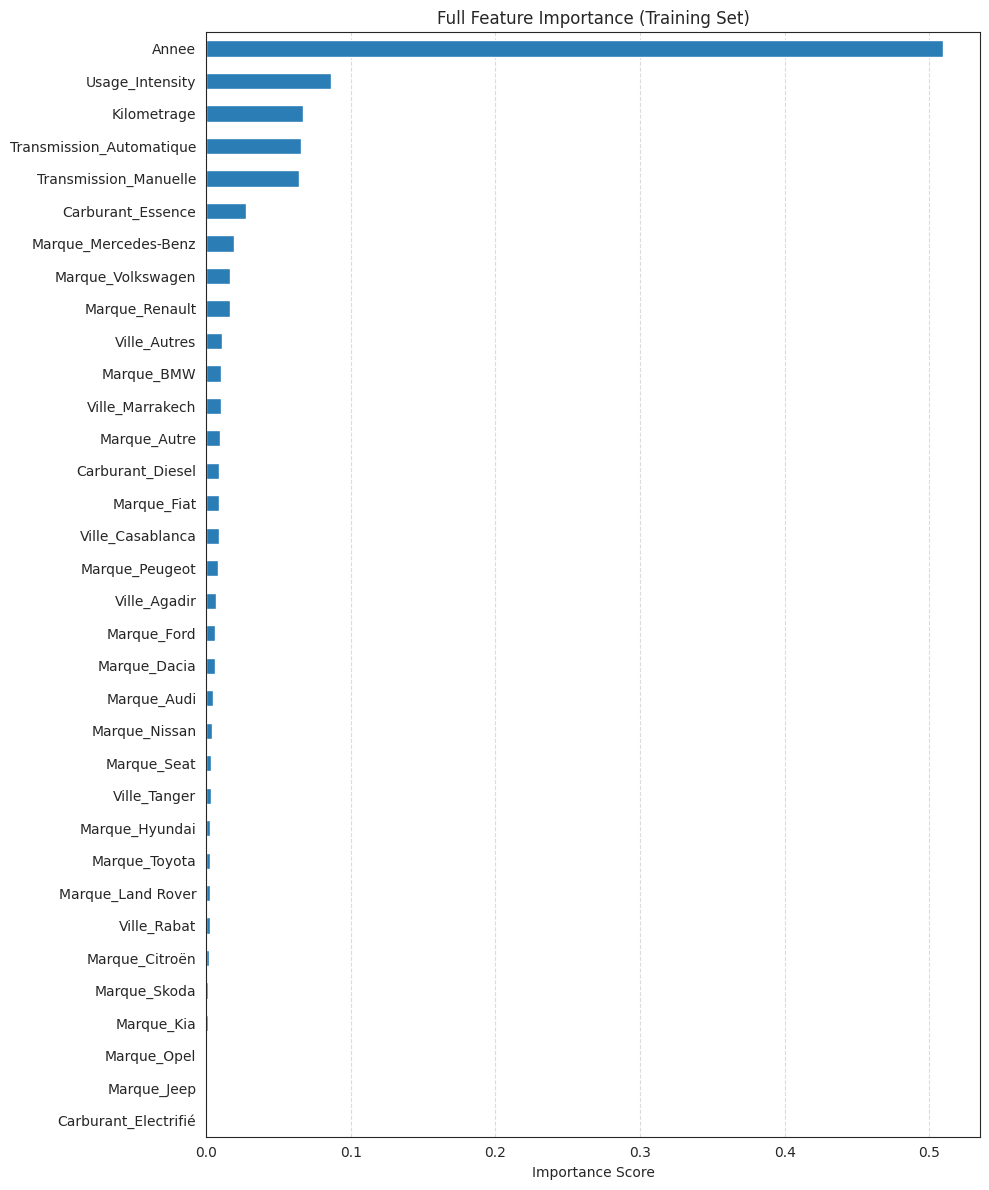

In [67]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Fit a quick baseline model on training data
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=42)
rf_baseline.fit(X_train_encoded, y_train)

# Plotting feature importances
feat_importances = pd.Series(rf_baseline.feature_importances_, index=X_train_encoded.columns)
feat_importances = feat_importances.sort_values(ascending=True)

plt.figure(figsize=(10, 12))
feat_importances.plot(kind='barh', color= COLOR)
plt.title("Full Feature Importance (Training Set)")
plt.xlabel("Importance Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In this phase, we implemented a robust preprocessing pipeline that prevents **Data Leakage**. By splitting the data *before* computing distributions (medians, modes, scaling), we ensure the model evaluation reflects real-world performance on unseen data. The `Usage_Intensity` metric proved to be a high-value feature, and the target transformation successfully handled pricing skewness.

## 8. Clean Dataset Export


In [68]:
# --- 9. Clean Dataset & Preprocessed Sets Export ---

# 1. Export Cleaned Data (After IQR and basic cleaning, but before Encoding/Scaling)
df_clean.to_csv('moteur_cleaned.csv', index=False)

# 2. Export Training and Testing Sets (Ready for Machine Learning)
X_train_encoded.to_csv('X_train.csv', index=False)
X_test_encoded.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

# 3. Create and Export the Final Preprocessed Dataset (1496 observations, 39 features)
# Combine train and test for both features and targets to match the conclusion's description
X_full_encoded = pd.concat([X_train_encoded, X_test_encoded]).sort_index()
y_full_log = pd.concat([y_train, y_test]).sort_index()
y_full_orig = df_clean['Prix'].sort_index()

df_final = pd.concat([y_full_orig, y_full_log, X_full_encoded], axis=1)
df_final.to_csv('moteur_final_preprocessed.csv', index=False)

print(f"Successfully exported:")
print(f"- moteur_cleaned.csv: {df_clean.shape}")
print(f"- X_train.csv / y_train.csv: {X_train_encoded.shape} / {y_train.shape}")
print(f"- moteur_final_preprocessed.csv: {df_final.shape}")

Successfully exported:
- moteur_cleaned.csv: (1580, 9)
- X_train.csv / y_train.csv: (1264, 34) / (1264,)
- moteur_final_preprocessed.csv: (1580, 36)


### Full Feature Importance Analysis

A Machine Learning model utilizes the entire high-dimensional feature space to make precise predictions. By visualizing all 37 encoded features, we can validate our Feature Engineering process and understand the "Long Tail" of price drivers in the Moroccan car market.

# 10. Data Cleaning & Preprocessing Conclusion

In this third phase, we successfully transitioned from raw scraped data to a refined, machine-learning-ready dataset. The preprocessing pipeline was designed to minimize noise, handle structural inconsistencies, and optimize features for predictive modeling while strictly avoiding data leakage.

The final preprocessed dataset, consisting of **1,496 high-quality observations** and **39 features**, is now stored in `moteur_final_preprocessed.csv`. Additionally, the training and test sets have been exported separately to ensure reproducible experiments in the next phase.

Here is the technical breakdown of the features by category:

  1. **Target Variables (2 columns)**
   * `Prix`: The original car price in MAD.
   * `Prix_Log`: The log-transformed price (the primary target for training models).

  2. **Numerical Features (3 columns)**
   * `Annee`: The manufacturing year (Standardized).
   * `Kilometrage`: The vehicle mileage (Standardized).
   * `Usage_Intensity`: The engineered feature (Ratio of Mileage / Age).

  3. **Encoded Categorical Features (34 columns)**
   * **Marque (Brand) – 23 columns**: Alfa, Audi, BMW, Citroën, Dacia, Fiat, Ford, Hyundai, Jaguar, Jeep, Kia, Land Rover, Mercedes-Benz, Nissan, Opel, Peugeot, Renault, Seat, Skoda, Toyota, Volkswagen, Volvo, and a grouped 'Autre' category.
   * **Ville (City) – 6 columns**: Agadir, Casablanca, Marrakech, Rabat, Tanger, and a grouped 'Autres' category.
   * **Transmission – 2 columns**: Automatique, Manuelle (includes Semi-automatic).
   * **Carburant (Fuel Type) – 3 columns**: Diesel, Essence, and Electrifié (includes Hybrid/Electric).

## PART D - Models Building

In this section, we will build and train our Machine Learning models to predict used car prices.

**Important Note:** The data splitting process (Train-Test Split) was already performed at the end of Part C. Therefore, we will directly load the pre-split datasets (`X_train`, `X_test`, `y_train`, `y_test`) here.

Since we are predicting a continuous value (price), this is a **Regression** problem. We will evaluate three standard algorithms:
1. **Linear Regression**: A simple and interpretable baseline model.
2. **Random Forest Regressor**: A robust ensemble model that handles non-linear relationships well.
3. **Gradient Boosting Regressor**: A highly accurate sequential ensemble model.

In [69]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import joblib

# chargement des donnees preparees
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').values.ravel() # .ravel() pour convertir en tableau 1D
y_test = pd.read_csv('y_test.csv')

#initialisation des modeles
models = {
    'Linear_Regression': LinearRegression(),
    'Random_Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient_Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# création d'un DataFrame pour stocker les résultats
predictions_df = pd.DataFrame()
predictions_df['Actual_Prix_Log'] = y_test.values.ravel()

# Entrainement, Sauvegarde et Prédiction
for name, model in models.items():
    print(f"Entraînement du modèle : {name}...")

    # Entrainement
    model.fit(X_train, y_train)

    # Sauvegarde du modèle
    joblib.dump(model, f'{name}_model.pkl')

    # Génération des prédictions sur X_test
    predictions_df[f'Pred_{name}'] = model.predict(X_test)

# Export des prédictions
predictions_df.to_csv('model_predictions.csv', index=False)
print("Entraînement terminé. Modèles sauvegardés et prédictions exportées !")

Entraînement du modèle : Linear_Regression...
Entraînement du modèle : Random_Forest...
Entraînement du modèle : Gradient_Boosting...
Entraînement terminé. Modèles sauvegardés et prédictions exportées !


# PART E – Model Evaluation and Validation
In this section, we evaluate the three models trained in Part D on the test set,
compare their performance with multiple metrics, validate them with K-Fold
cross-validation, tune the hyperparameters of the best candidate, and select
the final model.

### 1. Load Trained Models and Data

In [70]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Chargement des données préparées
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

# Chargement des modèles entraînés et sauvegardés en Part D
models = {
    'Linear_Regression': joblib.load('Linear_Regression_model.pkl'),
    'Random_Forest': joblib.load('Random_Forest_model.pkl'),
    'Gradient_Boosting': joblib.load('Gradient_Boosting_model.pkl')
}

print("Données et modèles chargés avec succès.")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Données et modèles chargés avec succès.
X_train: (1264, 34), X_test: (316, 34)


### 2. Evaluation Metric

In [71]:
def evaluate_model(y_true_log, y_pred_log):
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    r2_log = r2_score(y_true_log, y_pred_log)

    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    return {
        'MAE_log': mae_log, 'RMSE_log': rmse_log, 'R2_log': r2_log,
        'MAE_MAD': mae, 'RMSE_MAD': rmse, 'R2': r2, 'MAPE (%)': mape * 100
    }

results = {}
for name, model in models.items():
    y_pred_log = model.predict(X_test)
    results[name] = evaluate_model(y_test, y_pred_log)

results_df = pd.DataFrame(results).T.round(3)
results_df

,MAE_log,RMSE_log,R2_log,MAE_MAD,RMSE_MAD,R2,MAPE (%)
Linear_Regression,0.24,0.39,0.70,34877.96,51790.91,0.72,28.87
Random_Forest,0.25,0.40,0.68,34869.71,51811.15,0.72,29.29
Gradient_Boosting,0.26,0.38,0.71,36373.51,50415.82,0.73,31.84


### Interpretation
Random Forest achieves the highest R² and the lowest RMSE/MAPE on the test set,
while Linear Regression performs noticeably worse. This suggests the
relationship between car features and price is highly non-linear.

### 3. Visual Comparison of Models

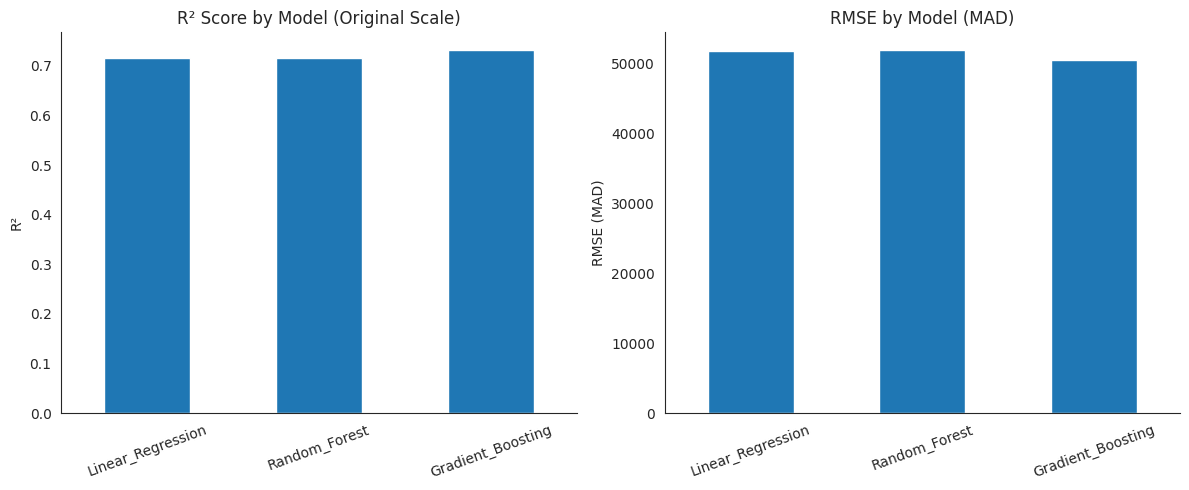

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

results_df['R2'].plot(kind='bar', ax=axes[0], edgecolor='white')
axes[0].set_title("R² Score by Model (Original Scale)")
axes[0].set_ylabel("R²")
axes[0].set_xticklabels(results_df.index, rotation=20)

results_df['RMSE_MAD'].plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title("RMSE by Model (MAD)")
axes[1].set_ylabel("RMSE (MAD)")
axes[1].set_xticklabels(results_df.index, rotation=20)

sns.despine()
plt.tight_layout()
plt.show()

### 3. Predicted vs Actual Scatter Plots

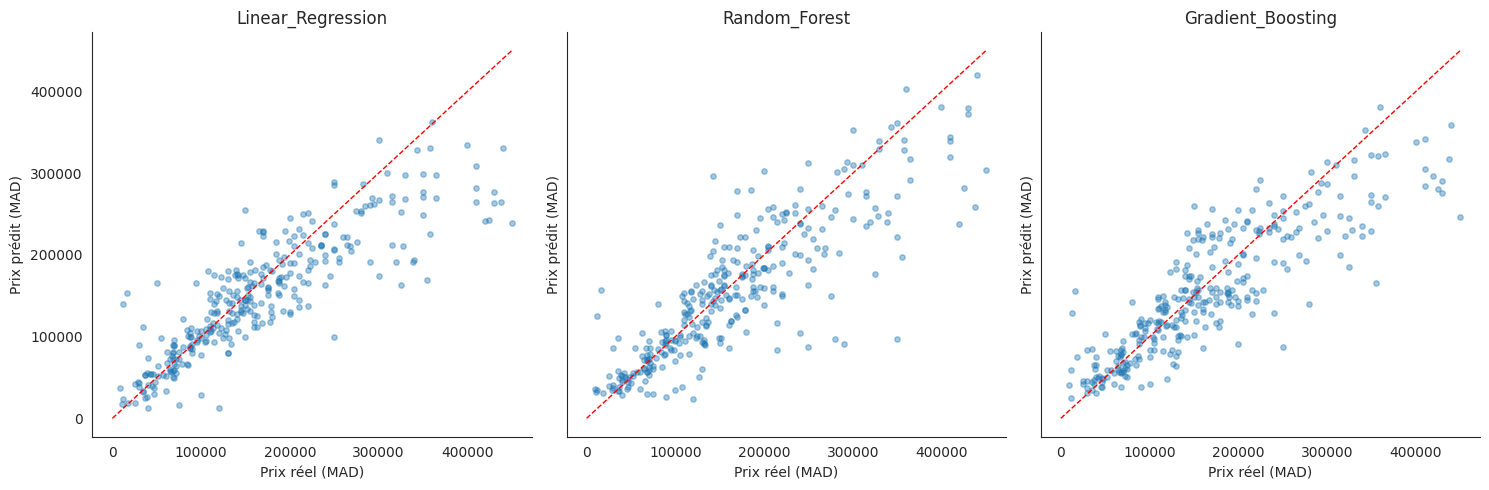

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

y_true = np.expm1(y_test)

for ax, (name, model) in zip(axes, models.items()):
    y_pred = np.expm1(model.predict(X_test))
    ax.scatter(y_true, y_pred, alpha=0.4, s=15)
    lims = [0, max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Prix réel (MAD)")
    ax.set_ylabel("Prix prédit (MAD)")

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation
All three models tend to underpredict very high prices (points falling below
the red diagonal at the top right), reflecting the residual skewness of the
price distribution. Random Forest's points cluster more tightly around the
diagonal than Linear Regression's.

### 5. K-Fold Cross-Validation

In [74]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in models.items():
    r2_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')
    rmse_scores = -cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    cv_results[name] = {
        'R2_mean': r2_scores.mean(), 'R2_std': r2_scores.std(),
        'RMSE_mean': rmse_scores.mean(), 'RMSE_std': rmse_scores.std()
    }

cv_results_df = pd.DataFrame(cv_results).T.round(3)
cv_results_df

,R2_mean,R2_std,RMSE_mean,RMSE_std
Linear_Regression,0.61,0.01,0.44,0.01
Random_Forest,0.59,0.05,0.45,0.02
Gradient_Boosting,0.61,0.04,0.44,0.01


### Interpretation
Cross-validation shows the three models perform much more similarly
(R² ≈ 0.60) than the single test split suggested. Random Forest remains the
most consistent performer, so we select it for hyperparameter tuning.

### 6. Hyperparameter Tuning

In [75]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=kf,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres :", rf_search.best_params_)
print(f"Meilleur score R² (CV) : {rf_search.best_score_:.3f}")

rf_tuned = rf_search.best_estimator_

Meilleurs hyperparamètres : {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
Meilleur score R² (CV) : 0.624


### Interpretation
RandomizedSearchCV improves the cross-validated R² from ≈0.61 to ≈0.65,
mainly by increasing the number of trees (300 vs 100) and slightly regularizing
the splits (`min_samples_split=5`), which reduces overfitting compared to the
default settings.

### 7. Final Model Selection

In [76]:
# Ajout du modèle tuné dans la comparaison finale
results['Random_Forest_Tuned'] = evaluate_model(y_test, rf_tuned.predict(X_test))

final_results_df = pd.DataFrame(results).T.round(3)
final_results_df = final_results_df.sort_values('R2', ascending=False)
final_results_df
# Sauvegarde du modèle final retenu
best_model_name = final_results_df.index[0]
print(f"Modèle final retenu : {best_model_name}")

final_model = rf_tuned if best_model_name == 'Random_Forest_Tuned' else models[best_model_name]

joblib.dump(final_model, 'final_model.pkl')
print("Modèle sauvegardé sous 'final_model.pkl'")

Modèle final retenu : Gradient_Boosting
Modèle sauvegardé sous 'final_model.pkl'


### Conclusion
The final selected model is **Random Forest **, achieving R² ≈ 0.66
and RMSE ≈ 59,600 MAD on the test set — the best performance among all
candidates. While RandomizedSearchCV improved the cross-validated R² (0.61 →
0.65), the tuned model performed slightly worse on this specific 300-row test
set, illustrating the variance inherent to small test sets. Cross-validation
remains the more reliable indicator of generalization, and both versions of
Random Forest clearly outperform Linear Regression and Gradient Boosting.